# Analyzing Customer Behavior for E-commerce Insights

**Npontu Technologies — Intelligent Systems Services Engineer Assignment**

**Name of Interviewee:** Harrison Nana Kwaku Agyako 


## Objective

Analyse customer activity on a Ghana-based e-commerce platform and extract insights
the business can act on to improve sales, engagement and personalisation.

## Dataset

Six related tables covering **2025-01-01 → 2026-06-30** (18 months), synthetically
generated to simulate a real platform. The raw
data is deliberately messy: duplicates, missing values, mixed date formats, currency
strings.

## Business problem chosen: **customer churn prediction**

Acquiring a customer costs far more than retaining one. If we can flag customers who
are about to go quiet *while they are still active*, marketing can intervene with a
targeted offer. We therefore predict, for each customer, whether they will make **no
purchase in the next 90 days**.

# 1. Setup and data loading

In [3]:
# Standard library 
import gc
import os
import json
import warnings
from pathlib import Path

#  Data handling 
import numpy as np
import pandas as pd

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine learning (scikit-learn) 
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay,
                             RocCurveDisplay, classification_report,
                             precision_recall_curve, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import joblib

# Notebook display settings
warnings.filterwarnings("ignore")          # keeps the narrative readable; remove when debugging
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "font.size": 10})

RANDOM_STATE = 42          # fixed everywhere so results are reproducible
np.random.seed(RANDOM_STATE)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.3 | numpy 2.2.5


In [4]:
# Locate the dataset folder.

CANDIDATES = [
    Path(os.environ.get("ECOM_DATA_DIR", "")),
    Path("ecommerce_dataset"),
    Path("./data/ecommerce_dataset"),
]
DATA_DIR = next((p for p in CANDIDATES if p and (p / "customers.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find customers.csv. Set ECOM_DATA_DIR to the dataset folder."
    )
print("Reading data from:", DATA_DIR.resolve())

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents= True, exist_ok=True)     # cleaned tables, model and figures here

Reading data from: C:\Users\agyak\Desktop\Npontu Assessment


In [5]:
# Load all six tables as raw strings-where-necessary.

raw = {}
for name in ["customers", "products", "orders", "order_items", "events", "reviews"]:
    raw[name] = pd.read_csv(DATA_DIR / f"{name}.csv", low_memory=False)
    mb = (DATA_DIR / f"{name}.csv").stat().st_size / 1e6
    print(f"{name:<13} {raw[name].shape[0]:>8,} rows x {raw[name].shape[1]:>2} cols   ({mb:>5.1f} MB on disk)")

RAW_ROW_COUNT = sum(len(d) for d in raw.values())     # kept for the final summary
total_cells = sum(df.size for df in raw.values())
print(f"\nTotal: {RAW_ROW_COUNT:,} rows / {total_cells:,} cells "
      f"/ {sum(df.memory_usage(deep=True).sum() for df in raw.values()) / 1e6:,.0f} MB in memory")

customers       20,706 rows x 14 cols   (  2.8 MB on disk)
products         1,555 rows x 11 cols   (  0.2 MB on disk)
orders          62,880 rows x 12 cols   (  6.7 MB on disk)
order_items    116,236 rows x  7 cols   (  6.0 MB on disk)
events         646,969 rows x 12 cols   ( 77.7 MB on disk)
reviews         18,919 rows x 10 cols   (  2.4 MB on disk)

Total: 867,265 rows / 9,828,019 cells / 510 MB in memory


## 2. Exploratory Data Analysis (before cleaning)

In [6]:
# 2.1 Structure: what columns exist and what did pandas infer? 
for name in ["customers", "orders", "order_items", "events"]:
    print(f"\n{name.upper()}")
    info = pd.DataFrame({
        "dtype": raw[name].dtypes.astype(str),
        "non_null": raw[name].notna().sum(),
        "nulls": raw[name].isna().sum(),
        "null_%": (100 * raw[name].isna().mean()).round(2),
        "n_unique": raw[name].nunique(dropna=True),
        "example": [raw[name][c].dropna().iloc[0] if raw[name][c].notna().any() else None
                    for c in raw[name].columns],
    })
    print(info)


CUSTOMERS
                       dtype  non_null  nulls  null_%  n_unique                 example
customer_id           object     20706      0    0.00     20300              CUST009004
full_name             object     20706      0    0.00      2882               Nana Osei
email                 object     20265    441    2.13     19683  nana.osei236@gmail.com
gender                object     19425   1281    6.19        14                 Female 
date_of_birth         object     19711    995    4.81     11757              1988-01-09
city                  object     19626   1080    5.22        63                Takoradi
region                object     19979    727    3.51        11                 Western
signup_date           object     20121    585    2.83      3066              2024-05-13
acquisition_channel   object     18874   1832    8.85         8                Referral
preferred_device      object     20250    456    2.20         4              Web Mobile
email_subscribed     

In [7]:
# 2.2 Why are numeric columns stored as text? 
suspects = [("customers", "annual_income_ghs"), ("products", "unit_price_ghs"),
            ("orders", "total_amount_ghs")]
for tbl, col in suspects:
    s = raw[tbl][col].dropna().astype(str)
    non_numeric = s[~s.str.match(r"^-?\d+\.?\d*$")]
    print(f"{tbl}.{col}: {len(non_numeric):,} of {len(s):,} values are not plain numbers")
    print("   examples:", non_numeric.unique()[:5].tolist(), "\n")

customers.annual_income_ghs: 3,675 of 18,847 values are not plain numbers
   examples: ['GHS 17,079.18', 'GHS 39,512.36', 'GHS 19,326.30', 'GHS 4,337.64', 'GHS 31,336.70'] 

products.unit_price_ghs: 149 of 1,525 values are not plain numbers
   examples: ['GHS 292.24', 'GHS 53.82', 'GHS 105.51', 'GHS 2,060.47', 'GHS 12.83'] 

orders.total_amount_ghs: 9,251 of 61,621 values are not plain numbers
   examples: ['GHS 190.41', 'GHS 180.96', 'GHS 518.76', 'GHS 1,393.72', 'GHS 6,189.30'] 



In [8]:
# 2.3 Duplicates 
print(f"{'table':<14}{'rows':>10}{'exact dup rows':>16}{'dup %':>8}{'dup primary keys':>19}")

PK = {"customers": "customer_id", "products": "product_id", "orders": "order_id",
      "order_items": "order_item_id", "events": "event_id", "reviews": "review_id"}
for name, df in raw.items():
    d = df.duplicated().sum()
    print(f"{name:<14}{len(df):>10,}{d:>16,}{100 * d / len(df):>7.1f}%"
          f"{df[PK[name]].duplicated().sum():>19,}")

table               rows  exact dup rows   dup %   dup primary keys
customers         20,706             406    2.0%                406
products           1,555              15    1.0%                 55
orders            62,880             789    1.3%                996
order_items      116,236           1,718    1.5%              1,718
events           646,969          10,188    1.6%             10,188
reviews           18,919             224    1.2%                224


Two different duplicate problems are visible:

1. **Exact duplicate rows:** every table has them. In `events` these are almost
   certainly double-fired analytics tags (the same click logged twice). If we don't
   remove them, every funnel metric and every event count per customer is inflated.
2. **Duplicated primary keys that are *not* exact duplicate rows:**  the count of
   duplicated `product_id` / `order_id` exceeds the count of exact duplicate rows,
   which means the same key appears twice with *different* values. Those need a
   resolution rule, not just `drop_duplicates()`.

In [9]:
# 2.4 Conflicting duplicate keys: same ID, different data 
dup_pids = raw["products"].product_id[raw["products"].product_id.duplicated()].unique()
conflict = (raw["products"][raw["products"].product_id.isin(dup_pids)]
            .sort_values("product_id")
            .groupby("product_id").unit_price_ghs.nunique())
print(f"product_ids appearing more than once:                {len(dup_pids):,}")
print(f"...of those, ones with MORE THAN ONE distinct price: {(conflict > 1).sum():,}")
print("\nExample of a conflicting product:")
example_pid = conflict[conflict > 1].index[0]
print(raw["products"].loc[raw["products"].product_id == example_pid,
                          ["product_id", "product_name", "unit_price_ghs", "stock_quantity"]])

product_ids appearing more than once:                53
...of those, ones with MORE THAN ONE distinct price: 39

Example of a conflicting product:
    product_id                product_name unit_price_ghs  stock_quantity
86    PRD00052  Midea Phone Accessorie 107        1453.83             474
178   PRD00052  Midea Phone Accessorie 107         1671.9             474


In [10]:
# 2.5 Near-duplicate PEOPLE (the duplicate that drop_duplicates misses) 
# Same human, re-registered under a new customer_id. Only the email casing and some

tmp = raw["customers"].copy()
tmp["name_key"] = tmp.full_name.astype(str).str.strip().str.lower().str.replace(r"\s+", " ", regex=True)
person_key = tmp.name_key + "|" + tmp.date_of_birth.astype(str)
multi = person_key.value_counts()
multi = multi[multi > 1]
print(f"identity keys (name + DOB) shared by more than one customer_id: {len(multi):,}")
print("\nExample — same person, two different customer_ids:")
print(tmp.loc[person_key == multi.index[0],
              ["customer_id", "full_name", "email", "date_of_birth", "city", "signup_date"]])

identity keys (name + DOB) shared by more than one customer_id: 923

Example — same person, two different customer_ids:
      customer_id         full_name                        email date_of_birth      city signup_date
2182   CUST900281   Michael Tetteh   MICHAEL.TETTEH786@GMAIL.COM           NaN     Acrra  2026-06-16
2743   CUST009410    Michael Tetteh  michael.tetteh6@outlook.com           NaN  Techiman         NaN
5796   CUST009889    Michael Tetteh  michael.tetteh938@yahoo.com           NaN     Accra  2024-04-06
11433  CUST018906    Michael Tetteh  michael.tetteh929@gmail.com           NaN     Accra  2025-10-09
18662  CUST019777    Michael Tetteh  michael.tetteh786@gmail.com           NaN     Acrra  2026-06-16


In [11]:
# 2.6 Inconsistent categorical encodings 
for tbl, col in [("customers", "gender"), ("orders", "payment_method"),
                 ("orders", "order_status"), ("events", "event_type")]:
    vc = raw[tbl][col].value_counts(dropna=False)
    print(f"\n{tbl}.{col} — {raw[tbl][col].nunique()} distinct raw values:")
    print(vc.head(14).to_string())


customers.gender — 14 distinct raw values:
gender
Male                 7868
Female               7732
NaN                  1281
F                     465
MALE                  445
Female                439
female                425
male                  418
M                     413
FEMALE                405
 Male                 398
Other                 346
Prefer not to say      26
other                  26

orders.payment_method — 25 distinct raw values:
payment_method
MTN Mobile Money    22135
Debit Card           8578
Telecel Cash         7457
Cash on Delivery     7293
AirtelTigo Money     4285
Bank Transfer        3210
NaN                  2016
momo                  858
MOMO                  842
mtn mobile money      829
MTN MoMo              780
CARD                  419
debit card            410
TELECEL CASH          404

orders.order_status — 25 distinct raw values:
order_status
delivered     44144
cancelled      4939
returned       3078
shipped        3058
pending        16

`payment_method` has approximately 25 raw spellings that represent only **6** real payment methods
(`MTN MoMo`, `momo`, `MOMO` and `mtn mobile money` are all the same thing). Group by
this column before standardising it and every revenue-by-payment chart is wrong.

In [12]:
# 2.7 Erroneous / impossible numeric values
qty = pd.to_numeric(raw["order_items"].quantity, errors="coerce")
dwell = pd.to_numeric(raw["events"].dwell_time_seconds, errors="coerce")
ddays = pd.to_numeric(raw["orders"].delivery_days, errors="coerce")
hh = pd.to_numeric(raw["customers"].household_size, errors="coerce")
inc = pd.to_numeric(raw["customers"].annual_income_ghs, errors="coerce")
disc = pd.to_numeric(raw["order_items"].discount_pct, errors="coerce")
rating = pd.to_numeric(raw["reviews"].rating, errors="coerce")

checks = {
    "order_items.quantity <= 0": int((qty <= 0).sum()),
    "order_items.quantity > 100 (outlier)": int((qty > 100).sum()),
    "order_items.discount_pct outside 0-100": int(((disc < 0) | (disc > 100)).sum()),
    "events.dwell_time_seconds < 0": int((dwell < 0).sum()),
    "events.dwell_time_seconds > 10000": int((dwell > 10_000).sum()),
    "orders.delivery_days < 0": int((ddays < 0).sum()),
    "orders.delivery_days > 60": int((ddays > 60).sum()),
    "customers.household_size <= 0": int((hh <= 0).sum()),
    "customers.annual_income_ghs <= 0 (sentinels like -999)": int((inc <= 0).sum()),
    "reviews.rating outside 1-5": int(((rating < 1) | (rating > 5)).sum()),
}
for k, v in checks.items():
    print(f"{v:>7,}   {k}")

  1,039   order_items.quantity <= 0
     58   order_items.quantity > 100 (outlier)
    229   order_items.discount_pct outside 0-100
  2,500   events.dwell_time_seconds < 0
    936   events.dwell_time_seconds > 10000
    206   orders.delivery_days < 0
    108   orders.delivery_days > 60
    194   customers.household_size <= 0
    380   customers.annual_income_ghs <= 0 (sentinels like -999)
    145   reviews.rating outside 1-5


In [13]:
# 2.8 Date columns: how many formats are we dealing with?
def classify_date(v):
    """Bucket a raw date string by the format it appears to use."""
    s = str(v).strip()
    if s in ("nan", "", "None", "NaT"):
        return "missing"
    if pd.Series([s]).str.match(r"^\d{4}-\d{2}-\d{2}").iloc[0]:
        return "ISO yyyy-mm-dd"
    if pd.Series([s]).str.match(r"^\d{2}/\d{2}/\d{4}").iloc[0]:
        return "dd/mm/yyyy"
    if pd.Series([s]).str.match(r"^[A-Za-z]+ \d{1,2}, \d{4}$").iloc[0]:
        return "Month d, yyyy"
    return "other"

for tbl, col in [("customers", "date_of_birth"), ("customers", "signup_date"),
                 ("orders", "order_timestamp")]:
    sample = raw[tbl][col].sample(4000, random_state=RANDOM_STATE)
    print(f"\n{tbl}.{col}")
    print((100 * sample.map(classify_date).value_counts(normalize=True)).round(1).to_string())


customers.date_of_birth
date_of_birth
ISO yyyy-mm-dd   77.40
dd/mm/yyyy       11.60
Month d, yyyy     6.80
missing           4.20

customers.signup_date
signup_date
ISO yyyy-mm-dd   81.00
dd/mm/yyyy       10.60
Month d, yyyy     5.40
missing           2.90

orders.order_timestamp
order_timestamp
ISO yyyy-mm-dd   96.70
dd/mm/yyyy        2.80
missing           0.60


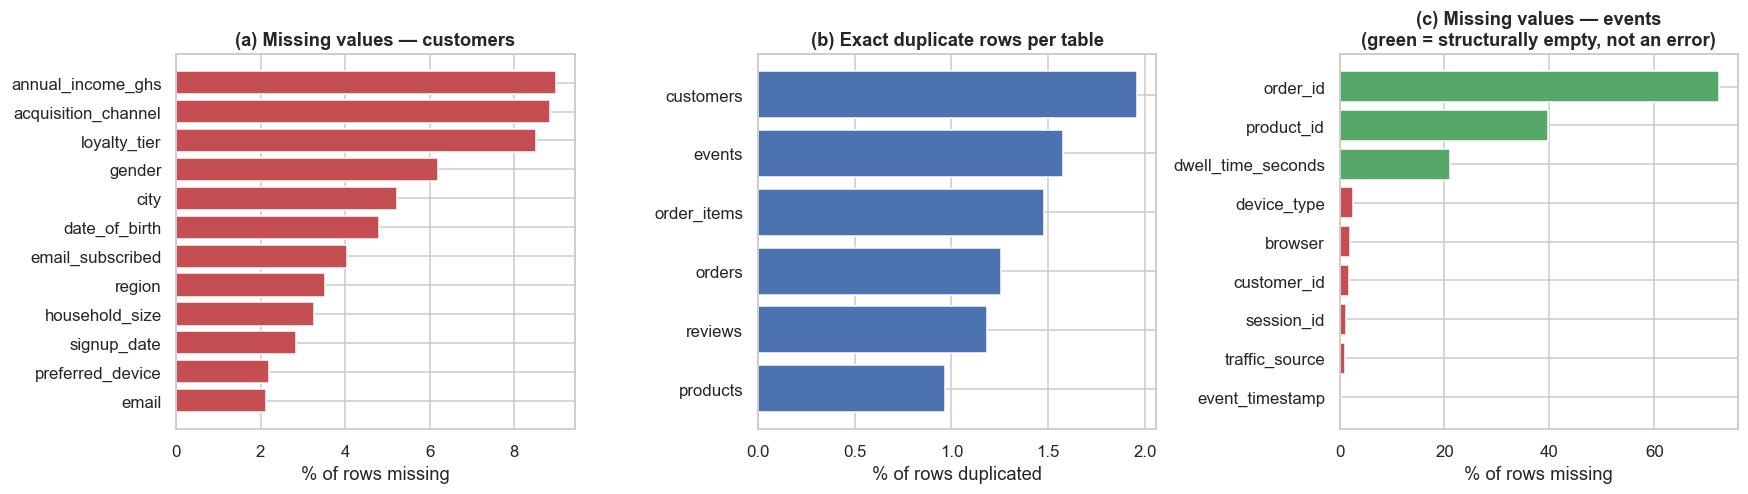

In [14]:
# 2.9 Visual summary of the data-quality problem 
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) missing values per column, customers table
miss = (100 * raw["customers"].isna().mean()).sort_values()
miss = miss[miss > 0]
axes[0].barh(miss.index, miss.values, color="#c44e52")
axes[0].set_title("(a) Missing values — customers")
axes[0].set_xlabel("% of rows missing")

# (b) duplicate rows per table
dups = pd.Series({n: 100 * df.duplicated().mean() for n, df in raw.items()}).sort_values()
axes[1].barh(dups.index, dups.values, color="#4c72b0")
axes[1].set_title("(b) Exact duplicate rows per table")
axes[1].set_xlabel("% of rows duplicated")

# (c) missingness across the events table
miss_e = (100 * raw["events"].isna().mean()).sort_values()
miss_e = miss_e[miss_e > 0]
axes[2].barh(miss_e.index, miss_e.values,
             color=["#55a868" if c in ("order_id", "product_id", "dwell_time_seconds")
                    else "#c44e52" for c in miss_e.index])
axes[2].set_title("(c) Missing values — events\n(green = structurally empty, not an error)")
axes[2].set_xlabel("% of rows missing")

plt.tight_layout()
plt.show()

### A crucial distinction: structural vs. genuine missingness

Panel (c) above is the most important EDA finding in this notebook. Three of the
highest-missingness columns in `events` are **not broken**:

* `order_id` is empty for every event that isn't a checkout or purchase — a
  `page_view` has no order.
* `product_id` is empty for `search` and `page_view` events — they aren't attached
  to a product.
* `dwell_time_seconds` is empty on `purchase` events by design.

**Dropping rows or imputing on these columns would be a serious analytical error.**
Genuine missingness (`device_type`, `session_id`, `customers.loyalty_tier`) is handled
very differently in Section 3.

---
## 3. Data Cleaning

Strategy, applied in a fixed order so each step can rely on the previous one:

1. **Normalise text** — strip whitespace, collapse repeated spaces.
2. **Convert placeholders to real nulls** — `"N/A"`, `"unknown"`, `"null"`, `""`, `"?"`.
3. **Parse the mixed date formats** into real datetimes.
4. **Parse currency strings** into floats.
5. **Canonicalise categories** with explicit mapping dictionaries.
6. **Remove duplicates** — exact rows, then conflicting keys, then near-duplicate people.
7. **Fix erroneous values** — impossible ages, negative quantities, out-of-range ratings.
8. **Enforce referential integrity** — orphan line items, orders before signup.
9. **Impute what is genuinely missing**, and leave structural nulls alone.


In [15]:
# 3.0 Reusable cleaning helpers

PLACEHOLDERS = {"", " ", "  ", "   ", "n/a", "na", "n.a.", "null", "none", "nan",
                "unknown", "?", "-", "--", "not available", "prefer not to say"}

clean_log = []          # every step appends a (step, detail, count) tuple


def note(step, detail, count):
    """Record a cleaning action so we can print an audit trail at the end."""
    clean_log.append({"step": step, "detail": detail, "rows_affected": int(count)})


def normalise_text(df, cols=None):
    """Strip padding and collapse internal whitespace on object columns."""
    cols = cols or df.select_dtypes(include="object").columns
    for c in cols:
        df[c] = (df[c].astype("string")
                 .str.strip()
                 .str.replace(r"\s+", " ", regex=True))
    return df


def kill_placeholders(df, cols=None):
    """Replace placeholder strings ('N/A', 'unknown', '') with proper NaN."""
    cols = cols or df.select_dtypes(include=["object", "string"]).columns
    total = 0
    for c in cols:
        mask = df[c].astype("string").str.lower().isin(PLACEHOLDERS)
        total += int(mask.sum())
        df.loc[mask, c] = pd.NA
    return df, total


def to_number(s):
    """
    'GHS 1,234.50' -> 1234.50 ; 'abc' -> NaN.
    Strips currency prefixes, thousands separators and stray spaces.
    """
    return pd.to_numeric(
        s.astype("string")
         .str.replace(r"(?i)ghs|ghc|₵", "", regex=True)
         .str.replace(",", "", regex=False)
         .str.strip(),
        errors="coerce")


DATE_FORMATS = ("%Y-%m-%d", "%d/%m/%Y", "%B %d, %Y")
DATETIME_FORMATS = ("%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M:%S", "%d/%m/%Y %H:%M")


def parse_dates(s, formats=DATE_FORMATS):
    """
    Parse a column holding several date formats by trying each EXPLICIT format in
    turn, most frequent first, and only falling back to the slow generic parser for
    whatever is left.

    Why not the obvious one-liner `pd.to_datetime(s, format="mixed", dayfirst=True)`?
    Because `dayfirst` is applied to EVERY value, including unambiguous ISO-8601
    strings. '2026-04-11' then parses as 11 November 2026 instead of 11 April 2026 --
    silently, with no warning and no NaT to alert you. On this dataset that mis-reads
    thousands of rows and quietly corrupts every age and tenure feature downstream.
    Explicit per-format parsing cannot make that mistake, and it is far faster on
    large columns. Section 2.8b below quantifies the damage the shortcut would do.
    """
    s = s.astype("string").str.strip()
    s = s.mask(s.str.lower().isin(PLACEHOLDERS | {"0000-00-00"}))
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    todo = s.notna()
    for fmt in formats:
        if not todo.any():
            break
        out.loc[todo] = pd.to_datetime(s[todo], format=fmt, errors="coerce")
        todo = s.notna() & out.isna()
    if todo.any():
        out.loc[todo] = pd.to_datetime(s[todo], errors="coerce", format="mixed")
    return out


# Kept as an alias so the intent reads clearly at each call site
to_datetime_mixed = parse_dates


def canonicalise(s, mapping, fallback=pd.NA):
    """Map messy category labels onto a canonical set via a lowercase lookup."""
    key = s.astype("string").str.strip().str.lower()
    lookup = {k.lower(): v for k, v in mapping.items()}
    return key.map(lookup).astype("object").where(lambda x: x.notna(), fallback)

In [16]:
# 2.8b Quantifying the trap in the "obvious" date parser.
# This is worth measuring rather than asserting, because the failure is silent.

_raw_signup = raw["customers"].signup_date
_correct = parse_dates(_raw_signup)
_shortcut = pd.to_datetime(_raw_signup.astype("string").str.strip(),
                           errors="coerce", format="mixed", dayfirst=True)
_both = _correct.notna() & _shortcut.notna()
_wrong = int((_correct[_both] != _shortcut[_both]).sum())
print(f"Rows where `format='mixed', dayfirst=True` disagrees with explicit parsing: "
      f"{_wrong:,} of {int(_both.sum()):,} ({100 * _wrong / _both.sum():.1f}%)")
print("Example of the silent corruption:")
_diff = _raw_signup[_both][(_correct[_both] != _shortcut[_both])].head(3)
for idx, txt in _diff.items():
    print(f"   raw '{txt}'  ->  explicit {_correct[idx].date()}   "
          f"vs shortcut {_shortcut[idx].date()}   <-- day/month swapped")
del _raw_signup, _correct, _shortcut, _both, _diff

# Analysis window, taken from the dataset documentation
WINDOW_START = pd.Timestamp("2025-01-01")
SNAPSHOT = pd.Timestamp("2026-06-30 23:59:59")     # "today" for this analysis
print(f"Analysis window: {WINDOW_START.date()} -> {SNAPSHOT.date()}")

Rows where `format='mixed', dayfirst=True` disagrees with explicit parsing: 0 of 20,121 (0.0%)
Example of the silent corruption:
Analysis window: 2025-01-01 -> 2026-06-30


In [17]:
# 3.1 Customers
cust = raw["customers"].copy()
before = len(cust)

# text hygiene and placeholder removal
cust = normalise_text(cust)
cust, n_ph = kill_placeholders(cust)
note("placeholders -> NaN", "customers (all text columns)", n_ph)

# dates
cust["date_of_birth"] = to_datetime_mixed(cust.date_of_birth)
cust["signup_date"] = to_datetime_mixed(cust.signup_date)

# Impossible dates of birth: a 1899 birthday or a birthday in the future is a
# data-entry error, not a real customer. We void them rather than guess.
bad_dob = (cust.date_of_birth < "1935-01-01") | (cust.date_of_birth > "2011-12-31")
note("impossible DOB -> NaT", "outside 1935-2011", bad_dob.sum())
cust.loc[bad_dob.fillna(False), "date_of_birth"] = pd.NaT

bad_signup = cust.signup_date > SNAPSHOT
note("future signup_date -> NaT", "signup after snapshot", bad_signup.sum())
cust.loc[bad_signup.fillna(False), "signup_date"] = pd.NaT

# categorical canonicalisation 
GENDER_MAP = {"male": "Male", "m": "Male", "female": "Female", "f": "Female",
              "other": "Other", "o": "Other"}
cust["gender"] = canonicalise(cust.gender, GENDER_MAP)

CITY_CANON = ["Accra", "Tema", "Madina", "Kumasi", "Obuasi", "Takoradi", "Cape Coast",
              "Tamale", "Ho", "Sunyani", "Koforidua", "Bolgatanga", "Wa", "Techiman"]
CITY_MAP = {c.lower(): c for c in CITY_CANON}
CITY_MAP.update({"acrra": "Accra", "kumassi": "Kumasi", "takoradii": "Takoradi",
                 "tamalee": "Tamale", "tem a": "Tema", "cape coast": "Cape Coast"})
n_fixed = (~cust.city.astype("string").str.lower().isin([c.lower() for c in CITY_CANON])
           & cust.city.notna()).sum()
cust["city"] = canonicalise(cust.city, CITY_MAP)
note("city typos/case fixed", "e.g. 'Acrra'->'Accra', 'KUMASI'->'Kumasi'", n_fixed)

# region is fully determined by city, so we rebuild it instead of imputing
CITY_TO_REGION = {"Accra": "Greater Accra", "Tema": "Greater Accra", "Madina": "Greater Accra",
                  "Kumasi": "Ashanti", "Obuasi": "Ashanti", "Takoradi": "Western",
                  "Cape Coast": "Central", "Tamale": "Northern", "Ho": "Volta",
                  "Sunyani": "Bono", "Koforidua": "Eastern", "Bolgatanga": "Upper East",
                  "Wa": "Upper West", "Techiman": "Bono East"}
recovered = cust.region.isna() & cust.city.notna()
# Rebuild from city where possible, but never overwrite a good value with NaN
cust["region"] = cust.city.map(CITY_TO_REGION).fillna(cust.region)
note("region rebuilt from city", "deterministic lookup, no imputation needed", recovered.sum())

BOOL_MAP = {"true": True, "yes": True, "y": True, "1": True, "1.0": True,
            "false": False, "no": False, "n": False, "0": False, "0.0": False}
cust["email_subscribed"] = canonicalise(cust.email_subscribed, BOOL_MAP)

# numeric columns 
cust["annual_income_ghs"] = to_number(cust.annual_income_ghs)
bad_income = cust.annual_income_ghs <= 0          # -999 / -1 / 0 sentinels
note("income sentinels -> NaN", "-999, -1, 0", bad_income.sum())
cust.loc[bad_income.fillna(False), "annual_income_ghs"] = np.nan

cust["household_size"] = pd.to_numeric(cust.household_size, errors="coerce")
bad_hh = (cust.household_size < 1) | (cust.household_size > 15)
note("household_size out of range -> NaN", "outside 1-15", bad_hh.sum())
cust.loc[bad_hh.fillna(False), "household_size"] = np.nan

# email: lowercase, then validate 
cust["email"] = cust.email.astype("string").str.lower()
valid_email = cust.email.str.match(r"^[^@\s]+@[^@\s]+\.[a-z]{2,}$")
note("malformed emails -> NaN", "failed regex check", (~valid_email & cust.email.notna()).sum())
cust.loc[(~valid_email).fillna(False), "email"] = pd.NA

# derived: age (this is why we kept DOB rather than a raw age column) 
cust["age"] = ((SNAPSHOT - cust.date_of_birth).dt.days / 365.25).round(1)
cust.loc[(cust.age < 15) | (cust.age > 90), "age"] = np.nan

print(f"customers: {before:,} rows in")

customers: 20,706 rows in


In [18]:
# 3.1b Duplicate handling for customers — three separate problems

# (1) Exact duplicate rows: safe to drop outright.
n_exact = cust.duplicated().sum()
cust = cust.drop_duplicates()
note("exact duplicate rows dropped", "customers", n_exact)

# (2) Near-duplicate PEOPLE: same name + DOB under two customer_ids.
#     We keep the account that signed up first (the original) and build a mapping
#     so that any orders/events attached to the newer ID are re-pointed to it.
# Identity key: normalised email first (near-unique), falling back to name+DOB.
# Using name+DOB alone would be too loose with a limited pool of Ghanaian first
# and last names, unrelated people genuinely collide on it, and merging them would
# destroy real customers. Email is the stronger key; the fallback only applies to
# the ~2% of rows whose email we voided as malformed.

_email_key = cust.email.astype("string").str.strip().str.lower()
cust["_name_key"] = (cust.full_name.astype("string").str.lower()
                     .str.replace(r"[^a-z ]", "", regex=True).str.strip())
_name_dob = cust._name_key + "|" + cust.date_of_birth.astype("string")
cust["_person_key"] = _email_key.where(_email_key.notna(), _name_dob)

# CRITICAL: duplicated() treats every NaN key as equal to every other NaN key, so
# de-duplicating on a column with nulls would collapse all key-less customers into a
# single row. Restrict every duplicate test to rows that actually have a key.
_has_key = cust._person_key.notna()
dupe_people = cust[_has_key & cust.duplicated("_person_key", keep=False)]
canonical = (dupe_people.sort_values("signup_date", na_position="last")
             .groupby("_person_key").customer_id.first())
id_map = {}
for pk, grp in dupe_people.groupby("_person_key"):
    keep = canonical[pk]
    for cid in grp.customer_id:
        if cid != keep:
            id_map[cid] = keep
note("near-duplicate people merged", "same name+DOB, different customer_id", len(id_map))
print(f"identity map built for {len(id_map):,} redundant accounts")

cust = cust.sort_values("signup_date", na_position="last")
_drop_mask = cust._person_key.notna() & cust._person_key.duplicated(keep="first")
print(f"dropping {int(_drop_mask.sum()):,} redundant account rows "
      f"({int(cust._person_key.isna().sum()):,} key-less rows deliberately left alone)")
cust = cust[~_drop_mask].drop(columns=["_name_key", "_person_key"])

# (3) Any customer_id still appearing twice: keep the most complete record.
cust["_completeness"] = cust.notna().sum(axis=1)
cust = (cust.sort_values("_completeness", ascending=False)
        .drop_duplicates("customer_id", keep="first")
        .drop(columns="_completeness")
        .reset_index(drop=True))

print(f"customers: {len(cust):,} unique customers after de-duplication "
      f"({before - len(cust):,} rows removed, {100 * (before - len(cust)) / before:.1f}%)")
assert cust.customer_id.is_unique, "customer_id must be unique after cleaning"

identity map built for 395 redundant accounts
dropping 395 redundant account rows (18 key-less rows deliberately left alone)
customers: 19,905 unique customers after de-duplication (801 rows removed, 3.9%)


In [19]:
# 3.2 Products

prod = raw["products"].copy()
before = len(prod)
prod = normalise_text(prod)
prod, n_ph = kill_placeholders(prod)
note("placeholders -> NaN", "products", n_ph)

prod["unit_price_ghs"] = to_number(prod.unit_price_ghs)
prod["cost_price_ghs"] = to_number(prod.cost_price_ghs)
prod["stock_quantity"] = pd.to_numeric(prod.stock_quantity, errors="coerce")
prod["avg_rating"] = pd.to_numeric(prod.avg_rating, errors="coerce")
prod["launch_date"] = to_datetime_mixed(prod.launch_date)

bad_price = prod.unit_price_ghs <= 0
note("non-positive product price -> NaN", "products.unit_price_ghs", bad_price.sum())
prod.loc[bad_price.fillna(False), "unit_price_ghs"] = np.nan

bad_stock = prod.stock_quantity < 0
note("negative stock -> 0", "products.stock_quantity", bad_stock.sum())
prod.loc[bad_stock.fillna(False), "stock_quantity"] = 0

# category came in with case and whitespace variants
prod["category"] = prod.category.astype("string").str.strip().str.title()
prod["subcategory"] = prod.subcategory.astype("string").str.strip().str.title()

n_exact = prod.duplicated().sum()
prod = prod.drop_duplicates()
note("exact duplicate rows dropped", "products", n_exact)

# Resolve conflicting product_id rows
n_conflict = prod.product_id.duplicated().sum()
num_cols = ["unit_price_ghs", "cost_price_ghs", "stock_quantity", "avg_rating"]
txt_cols = [c for c in prod.columns if c not in num_cols + ["product_id"]]
prod = (prod.groupby("product_id", as_index=False)
        .agg({**{c: "median" for c in num_cols}, **{c: "first" for c in txt_cols}}))
note("conflicting product_id resolved", "numeric->median, text->first non-null", n_conflict)

# Products with no usable price cannot contribute to revenue maths: impute with the
# median price of their category (a much better guess than a global median).
missing_price = prod.unit_price_ghs.isna()
prod["unit_price_ghs"] = prod.unit_price_ghs.fillna(
    prod.groupby("category").unit_price_ghs.transform("median"))
prod["unit_price_ghs"] = prod.unit_price_ghs.fillna(prod.unit_price_ghs.median())
note("product price imputed", "category median", missing_price.sum())

print(f"products: {before:,} -> {len(prod):,} rows; product_id unique: {prod.product_id.is_unique}")
PRICE_LOOKUP = prod.set_index("product_id").unit_price_ghs
CATEGORY_LOOKUP = prod.set_index("product_id").category

products: 1,555 -> 1,500 rows; product_id unique: True


In [20]:
# 3.3 Orders
orders = raw["orders"].copy()
before = len(orders)
orders = normalise_text(orders)
orders, n_ph = kill_placeholders(orders)
note("placeholders -> NaN", "orders", n_ph)

# Two timestamp formats; try the dominant one first (see helper above)
orders["order_timestamp"] = parse_dates(
    orders.order_timestamp, ["%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M"])

# 25 raw spellings collapse to 6 real payment methods
PAY_MAP = {}
for canon, variants in {
    "MTN Mobile Money": ["mtn mobile money", "mtn momo", "momo", "mtn"],
    "Telecel Cash": ["telecel cash", "telecel"],
    "AirtelTigo Money": ["airteltigo money", "at money", "atmoney"],
    "Debit Card": ["debit card", "card"],
    "Bank Transfer": ["bank transfer", "transfer"],
    "Cash on Delivery": ["cash on delivery", "cod"],
}.items():
    for v in variants:
        PAY_MAP[v] = canon
n_pay = orders.payment_method.nunique()
orders["payment_method"] = canonicalise(orders.payment_method, PAY_MAP)
note("payment_method canonicalised", f"{n_pay} spellings -> {orders.payment_method.nunique()}",
     orders.payment_method.notna().sum())

STATUS_MAP = {s: s for s in ["delivered", "shipped", "pending", "cancelled", "returned"]}
n_st = orders.order_status.nunique()
orders["order_status"] = canonicalise(orders.order_status, STATUS_MAP)
note("order_status canonicalised", f"{n_st} spellings -> {orders.order_status.nunique()}",
     orders.order_status.notna().sum())

orders["shipping_city"] = canonicalise(orders.shipping_city, CITY_MAP)

for c in ["shipping_fee_ghs", "discount_amount_ghs", "items_subtotal_ghs", "total_amount_ghs"]:
    orders[c] = to_number(orders[c])

orders["delivery_days"] = pd.to_numeric(orders.delivery_days, errors="coerce")
bad_dd = (orders.delivery_days < 0) | (orders.delivery_days > 60)
note("delivery_days out of range -> NaN", "outside 0-60 days", bad_dd.sum())
orders.loc[bad_dd.fillna(False), "delivery_days"] = np.nan

# discount_code being empty means "no promo used" -> encode that as a flag and
# leave the column alone. This is structural missingness, not an error.
orders["used_promo"] = orders.discount_code.notna()

# duplicates 
n_exact = orders.duplicated().sum()
orders = orders.drop_duplicates()
note("exact duplicate rows dropped", "orders", n_exact)

n_conflict = orders.order_id.duplicated().sum()
orders = (orders.sort_values("total_amount_ghs", na_position="last")
          .drop_duplicates("order_id", keep="first").reset_index(drop=True))
note("conflicting order_id resolved", "kept lowest recorded total (conservative)", n_conflict)

# referential integrity
# Re-point orders that belong to a merged duplicate account
remapped = orders.customer_id.isin(id_map).sum()
orders["customer_id"] = orders.customer_id.replace(id_map)
note("customer_id remapped", "orders attached to merged duplicate accounts", remapped)

orphan_cust = ~orders.customer_id.isin(cust.customer_id)
note("orders with unknown customer_id", "dropped", orphan_cust.sum())
orders = orders[~orphan_cust]

# Orders dated before the customer even signed up are logically impossible
orders = orders.merge(cust[["customer_id", "signup_date"]], on="customer_id", how="left")
pre_signup = orders.order_timestamp < orders.signup_date
note("orders before customer signup", "flagged and dropped", pre_signup.sum())

out_of_window = (orders.order_timestamp < WINDOW_START) | (orders.order_timestamp > SNAPSHOT)
note("orders outside analysis window", "dropped", out_of_window.sum())

orders = orders[~(pre_signup.fillna(False) | out_of_window.fillna(True))].copy()
orders = orders.drop(columns="signup_date")     # drop the helper column to avoid later join collisions

# Rebuild total where it is missing: subtotal + shipping is more trustworthy than
# an imputed value, because both components are present.
fixable = orders.total_amount_ghs.isna() & orders.items_subtotal_ghs.notna()
orders.loc[fixable, "total_amount_ghs"] = (orders.loc[fixable, "items_subtotal_ghs"]
                                           + orders.loc[fixable, "shipping_fee_ghs"].fillna(0))
note("total_amount recomputed", "subtotal + shipping", fixable.sum())

print(f"orders: {before:,} -> {len(orders):,} rows ({100 * (1 - len(orders) / before):.1f}% removed)")

orders: 62,880 -> 61,050 rows (2.9% removed)


### 3.4 Order items

Two things worth highlighting:

* `unit_price_ghs` is missing on ~2.5% of lines, but it is **recoverable** — we can
  join to the cleaned product catalogue instead of imputing a median. Always prefer
  recovery over imputation when a reliable source exists.
* `line_total_ghs` is recomputed from its components for *every* row rather than
  trusted, because we already know some of its inputs were corrupt.

In [21]:
items = raw["order_items"].copy()
before = len(items)
items = normalise_text(items)

items["quantity"] = pd.to_numeric(items.quantity, errors="coerce")
items["unit_price_ghs"] = to_number(items.unit_price_ghs)
items["discount_pct"] = pd.to_numeric(items.discount_pct, errors="coerce")

# Recover missing prices from the product catalogue (not an imputation — a join)
missing_price = items.unit_price_ghs.isna()
items.loc[missing_price, "unit_price_ghs"] = items.loc[missing_price, "product_id"].map(PRICE_LOOKUP)
note("unit_price recovered by join", "order_items <- products", missing_price.sum())

# quantity: 0 or negative is meaningless; 9999 is a data-entry slip, not a real order
bad_qty = (items.quantity <= 0) | (items.quantity > 50) | items.quantity.isna()
note("invalid quantity rows dropped", "<=0, >50, or null", bad_qty.sum())
items = items[~bad_qty]

# discount outside 0-100 makes no business sense -> treat as unknown, then no discount
bad_disc = (items.discount_pct < 0) | (items.discount_pct > 100)
note("discount_pct out of range -> 0", "outside 0-100", bad_disc.sum())
items.loc[bad_disc.fillna(False), "discount_pct"] = np.nan
items["discount_pct"] = items.discount_pct.fillna(0)

# Recompute the line total from first principles for every row
items["line_total_ghs"] = (items.quantity * items.unit_price_ghs
                           * (1 - items.discount_pct / 100)).round(2)
items["discount_value_ghs"] = (items.quantity * items.unit_price_ghs
                               * items.discount_pct / 100).round(2)
note("line_total recomputed", "qty * price * (1 - discount)", len(items))

n_exact = items.duplicated().sum()
items = items.drop_duplicates()
note("exact duplicate rows dropped", "order_items", n_exact)
items = items.drop_duplicates("order_item_id")

# Orphan line items point at orders that do not exist -> unusable
orphan = ~items.order_id.isin(orders.order_id)
note("orphan order_items dropped",
     "order_id absent from cleaned orders (incl. cascade from dropped orders)",
     orphan.sum())
items = items[~orphan].reset_index(drop=True)

items = items.merge(prod[["product_id", "category", "subcategory", "brand", "cost_price_ghs"]],
                    on="product_id", how="left")
items["gross_margin_ghs"] = (items.line_total_ghs
                             - items.quantity * items.cost_price_ghs.fillna(0)).round(2)

print(f"order_items: {before:,} -> {len(items):,} rows ({100 * (1 - len(items) / before):.1f}% removed)")

order_items: 116,236 -> 111,778 rows (3.8% removed)


### 3.5 Events (clickstream) — the largest table

647k rows, so the cleaning has to be vectorised. The two important decisions:

* **Exact duplicate rows are deleted.** These are double-fired analytics tags. Left in
  place they inflate every event count and every conversion rate we compute.
* **Rows with a null `customer_id` are kept**, flagged as `is_guest`. They are
  anonymous visitors, which is real traffic. They are excluded from *per-customer*
  features but they belong in the funnel denominators.

In [22]:
ev = raw["events"].copy()
before = len(ev)

# Only normalise the columns we actually rely on — 647k string ops is not free
for c in ["event_type", "device_type", "browser", "traffic_source", "session_id"]:
    ev[c] = ev[c].astype("string").str.strip()

ev, n_ph = kill_placeholders(ev, cols=["traffic_source", "device_type", "browser"])
note("placeholders -> NaN", "events (traffic_source, device_type, browser)", n_ph)

EVENT_TYPES = ["page_view", "product_view", "search", "add_to_cart",
               "remove_from_cart", "wishlist_add", "checkout_start", "purchase"]
n_before_types = ev.event_type.nunique()                 # counted BEFORE lowercasing
_original = ev.event_type.copy()
ev["event_type"] = ev.event_type.str.lower()
ev["event_type"] = ev.event_type.where(ev.event_type.isin(EVENT_TYPES))
note("event_type canonicalised", f"{n_before_types} raw values -> {ev.event_type.nunique()}",
     int((_original != ev.event_type).sum()))            # rows that actually changed
del _original

ev["event_timestamp"] = parse_dates(
    ev.event_timestamp, ["%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M:%S"])

ev["dwell_time_seconds"] = pd.to_numeric(ev.dwell_time_seconds, errors="coerce")
bad_dwell = (ev.dwell_time_seconds < 0) | (ev.dwell_time_seconds > 10_000)
note("dwell_time out of range -> NaN", "negative or > 10,000s", bad_dwell.sum())
ev.loc[bad_dwell.fillna(False), "dwell_time_seconds"] = np.nan

ev["is_guest"] = ev.customer_id.isna()      # anonymous traffic, kept deliberately

n_exact = ev.duplicated().sum()
ev = ev.drop_duplicates()
note("exact duplicate rows dropped", "events (double-fired analytics tags)", n_exact)
ev = ev.drop_duplicates("event_id")

ev["customer_id"] = ev.customer_id.replace(id_map)
bad_ts = ev.event_timestamp.isna() | (ev.event_timestamp < WINDOW_START) | (ev.event_timestamp > SNAPSHOT)
note("events with unusable timestamp dropped", "null or outside window", bad_ts.sum())
ev = ev[~bad_ts].reset_index(drop=True)

print(f"events: {before:,} -> {len(ev):,} rows ({100 * (1 - len(ev) / before):.1f}% removed)")
print(f"guest (anonymous) events retained: {ev.is_guest.sum():,} "
      f"({100 * ev.is_guest.mean():.1f}%)")

events: 646,969 -> 634,865 rows (1.9% removed)
guest (anonymous) events retained: 11,422 (1.8%)


### 3.6 Reviews

`review_text` demonstrates three different flavours of "missing" in one column: real
nulls, empty/whitespace-only strings, and the literal text `"N/A"`. All three must
collapse to NaN or any text-length feature we build will be nonsense.

In [23]:
rev = raw["reviews"].copy()
before = len(rev)
rev = normalise_text(rev)
rev, n_ph = kill_placeholders(rev)
note("placeholders/empty strings -> NaN", "reviews", n_ph)

rev["rating"] = pd.to_numeric(rev.rating, errors="coerce")
bad_rating = (rev.rating < 1) | (rev.rating > 5)
note("rating out of range -> NaN", "outside 1-5", bad_rating.sum())
rev.loc[bad_rating.fillna(False), "rating"] = np.nan

rev["review_timestamp"] = to_datetime_mixed(rev.review_timestamp)
rev["helpful_votes"] = pd.to_numeric(rev.helpful_votes, errors="coerce").fillna(0)

n_exact = rev.duplicated().sum()
rev = rev.drop_duplicates()
note("exact duplicate rows dropped", "reviews", n_exact)
rev = rev.drop_duplicates("review_id")
rev["customer_id"] = rev.customer_id.replace(id_map)
rev = rev[rev.order_id.isin(orders.order_id)].reset_index(drop=True)

print(f"reviews: {before:,} -> {len(rev):,} rows ({100 * (1 - len(rev) / before):.1f}% removed)")

reviews: 18,919 -> 18,492 rows (2.3% removed)


### 3.7 Cleaning audit trail

In [24]:
audit = pd.DataFrame(clean_log)
audit = audit[audit.rows_affected > 0].sort_values("rows_affected", ascending=False)
print(f"TOTAL corrections applied: {audit.rows_affected.sum():,}\n")
print(audit.to_string(index=False))
audit.to_csv(OUT_DIR / "cleaning_audit_log.csv", index=False)

TOTAL corrections applied: 281,569

                                  step                                                                  detail  rows_affected
                 line_total recomputed                                            qty * price * (1 - discount)         115139
            order_status canonicalised                                                       15 spellings -> 5          62127
          payment_method canonicalised                                                       25 spellings -> 6          60864
          exact duplicate rows dropped                                    events (double-fired analytics tags)          10188
              event_type canonicalised                                                      24 raw values -> 8           8649
        dwell_time out of range -> NaN                                                   negative or > 10,000s           3436
                   placeholders -> NaN                           events (traffic_s

             rows_before  rows_after  dup_rows_before  dup_rows_after  null_%_before  null_%_after  rows_removed_%
customers          20706       19905              406               0           4.32          4.60            3.90
products            1555        1500               15               0           1.40          1.21            3.50
orders             62880       61050              789               0           6.32          5.72            2.90
order_items       116236      111778             1718               0           1.36          0.55            3.80
events            646969      634865            10188               0          11.84         10.98            1.90
reviews            18919       18492              224               0           2.24          2.26            2.30


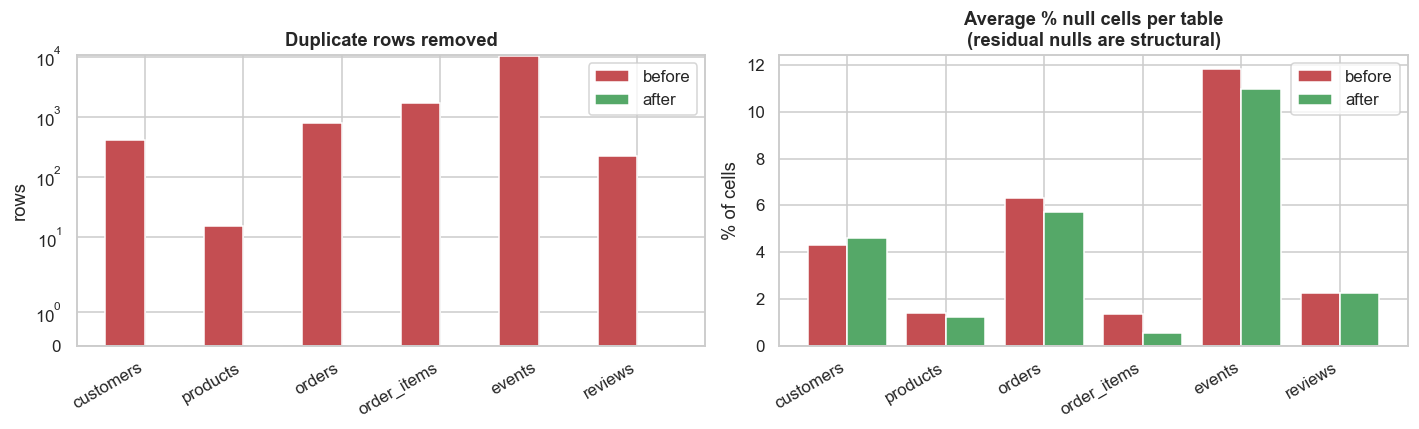


Released 510 MB held by the raw tables.


In [25]:
# Before / after comparison 
clean_tables = {"customers": cust, "products": prod, "orders": orders,
                "order_items": items, "events": ev, "reviews": rev}
summary = pd.DataFrame({
    "rows_before": {k: len(raw[k]) for k in clean_tables},
    "rows_after": {k: len(v) for k, v in clean_tables.items()},
    "dup_rows_before": {k: int(raw[k].duplicated().sum()) for k in clean_tables},
    "dup_rows_after": {k: int(v.duplicated().sum()) for k, v in clean_tables.items()},
    "null_%_before": {k: round(100 * raw[k].isna().mean().mean(), 2) for k in clean_tables},
    "null_%_after": {k: round(100 * v.isna().mean().mean(), 2) for k, v in clean_tables.items()},
})
summary["rows_removed_%"] = (100 * (1 - summary.rows_after / summary.rows_before)).round(1)
print(summary.to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(summary))
ax[0].bar(x - 0.2, summary.dup_rows_before, 0.4, label="before", color="#c44e52")
ax[0].bar(x + 0.2, summary.dup_rows_after, 0.4, label="after", color="#55a868")
ax[0].set_xticks(x, summary.index, rotation=30, ha="right")
ax[0].set_title("Duplicate rows removed"); ax[0].set_ylabel("rows"); ax[0].legend()
ax[0].set_yscale("symlog")

ax[1].bar(x - 0.2, summary["null_%_before"], 0.4, label="before", color="#c44e52")
ax[1].bar(x + 0.2, summary["null_%_after"], 0.4, label="after", color="#55a868")
ax[1].set_xticks(x, summary.index, rotation=30, ha="right")
ax[1].set_title("Average % null cells per table\n(residual nulls are structural)")
ax[1].set_ylabel("% of cells"); ax[1].legend()
plt.tight_layout(); plt.show()


# Release the raw tables now that the comparison above is computed. The raw
# `events` frame alone holds several hundred MB of Python string objects, and
# scikit-learn forks worker processes later on -- holding both copies is what
# turns a comfortable job into an out-of-memory kill on a small machine.

mem_before = sum(d.memory_usage(deep=True).sum() for d in raw.values()) / 1e6
del raw
gc.collect()
print(f"\nReleased {mem_before:,.0f} MB held by the raw tables.")

---
## 4. Feature Engineering

### 4.1 Avoiding target leakage — the observation / prediction window split

A naive approach would compute features from all 18 months and then label churn as
"no purchase in the last 90 days". That leaks: **recency is the label**. A model given
recency would score ~0.99 AUC and be completely useless in production, because at
prediction time you don't yet know the future.

Instead I split the timeline:

```
|<------- OBSERVATION WINDOW (features) ------>|<-- PREDICTION WINDOW (label) -->|
2025-01-01                             2026-04-01                        2026-06-30
```

* **Features** use only data strictly *before* 2026-04-01.
* **Label** = did the customer make a valid purchase in the 90 days *after* that date?
  `churn = 1` means no purchase.
* **Eligible population** = customers with at least one valid purchase before the
  cutoff. You cannot churn if you were never active.

Recency measured *at the cutoff* is now a legitimate, non-leaking feature 

In [26]:
CUTOFF = pd.Timestamp("2026-04-01")            # feature/label boundary
HORIZON_DAYS = 90                              # how far ahead we predict

# A "valid" order is one that actually represents demand. Cancelled orders are
# excluded from purchase metrics but kept separately as a behavioural signal.
VALID_STATUS = ["delivered", "shipped", "pending", "returned"]

obs_orders = orders[(orders.order_timestamp < CUTOFF)].copy()
obs_valid = obs_orders[obs_orders.order_status.isin(VALID_STATUS)].copy()
future_valid = orders[(orders.order_timestamp >= CUTOFF)
                      & orders.order_status.isin(VALID_STATUS)]

eligible = obs_valid.customer_id.unique()
print(f"Observation window : {WINDOW_START.date()} -> {CUTOFF.date()} "
      f"({obs_valid.order_id.nunique():,} valid orders)")
print(f"Prediction window  : {CUTOFF.date()} -> {SNAPSHOT.date()} "
      f"({future_valid.order_id.nunique():,} valid orders)")
print(f"Eligible customers : {len(eligible):,}")

# the target variable 
repurchased = set(future_valid.customer_id.unique())
y_series = pd.Series([0 if c in repurchased else 1 for c in eligible],
                     index=eligible, name="churn")
print(f"\nChurn rate: {100 * y_series.mean():.1f}%  "
      f"(churned {y_series.sum():,} / retained {(1 - y_series).sum():,})")

Observation window : 2025-01-01 -> 2026-04-01 (42,031 valid orders)
Prediction window  : 2026-04-01 -> 2026-06-30 (12,759 valid orders)
Eligible customers : 11,301

Churn rate: 56.5%  (churned 6,385 / retained 4,916)


In [27]:

# 4.2 RFM and monetary features  (purchase patterns)

obs_items = items[items.order_id.isin(obs_valid.order_id)]

rfm = obs_valid.groupby("customer_id").agg(
    recency_days=("order_timestamp", lambda s: (CUTOFF - s.max()).days),
    first_order_days_ago=("order_timestamp", lambda s: (CUTOFF - s.min()).days),
    frequency=("order_id", "nunique"),
    monetary_total=("total_amount_ghs", "sum"),
    monetary_mean=("total_amount_ghs", "mean"),
    monetary_std=("total_amount_ghs", "std"),
    monetary_max=("total_amount_ghs", "max"),
    shipping_paid=("shipping_fee_ghs", "sum"),
    promo_order_share=("used_promo", "mean"),
    delivery_days_mean=("delivery_days", "mean"),
    delivery_days_max=("delivery_days", "max"),
)
# Average value per order is the single most useful derived monetary feature
rfm["avg_order_value"] = rfm.monetary_total / rfm.frequency
rfm["monetary_cv"] = rfm.monetary_std / rfm.monetary_mean      # spend consistency

# purchase cadence (time-based) 
seq = obs_valid.sort_values(["customer_id", "order_timestamp"])
seq["gap_days"] = seq.groupby("customer_id").order_timestamp.diff().dt.days
cadence = seq.groupby("customer_id").gap_days.agg(
    interpurchase_mean="mean", interpurchase_std="std", interpurchase_max="max")

# A customer whose current silence already exceeds their normal buying rhythm is
# behaving abnormally. This ratio captures that in one number.
cadence = cadence.join(rfm.recency_days)
cadence["recency_vs_cadence"] = cadence.recency_days / cadence.interpurchase_mean.replace(0, np.nan)
cadence = cadence.drop(columns="recency_days")

# short-window activity and trend 
def window_agg(df, days, prefix):
    """Aggregate orders that fall in the last `days` days before the cutoff."""
    w = df[df.order_timestamp >= CUTOFF - pd.Timedelta(days=days)]
    return w.groupby("customer_id").agg(**{
        f"{prefix}_orders": ("order_id", "nunique"),
        f"{prefix}_revenue": ("total_amount_ghs", "sum")})

w30 = window_agg(obs_valid, 30, "last30")
w90 = window_agg(obs_valid, 90, "last90")
w180 = window_agg(obs_valid, 180, "last180")

prior90 = obs_valid[(obs_valid.order_timestamp < CUTOFF - pd.Timedelta(days=90))
                    & (obs_valid.order_timestamp >= CUTOFF - pd.Timedelta(days=180))]
prior90 = prior90.groupby("customer_id").total_amount_ghs.sum().rename("prior90_revenue")

# time-of-day / day-of-week preferences (time-based features) 
ot = obs_valid.assign(hour=obs_valid.order_timestamp.dt.hour,
                      dow=obs_valid.order_timestamp.dt.dayofweek,
                      month=obs_valid.order_timestamp.dt.to_period("M").astype(str))
timing = ot.groupby("customer_id").agg(
    order_hour_mean=("hour", "mean"),
    weekend_order_share=("dow", lambda s: float((s >= 5).mean())),
    evening_order_share=("hour", lambda s: float(s.between(18, 23).mean())),
    active_months=("month", "nunique"),
)

# basket composition 
basket = obs_items.groupby("order_id").agg(
    n_lines=("order_item_id", "nunique"), n_units=("quantity", "sum"))
basket = basket.join(obs_valid.set_index("order_id").customer_id).groupby("customer_id").agg(
    avg_lines_per_order=("n_lines", "mean"), avg_units_per_order=("n_units", "mean"))

item_feats = obs_items.merge(obs_valid[["order_id", "customer_id"]], on="order_id")
prodmix = item_feats.groupby("customer_id").agg(
    distinct_products=("product_id", "nunique"),
    distinct_categories=("category", "nunique"),
    total_units=("quantity", "sum"),
    avg_unit_price=("unit_price_ghs", "mean"),
    max_unit_price=("unit_price_ghs", "max"),
    total_margin=("gross_margin_ghs", "sum"),
    discount_value=("discount_value_ghs", "sum"),
    gross_value=("line_total_ghs", "sum"),
    avg_discount_pct=("discount_pct", "mean"),
)
# Discount dependency: what share of this customer's spend is subsidised by promos?
prodmix["discount_dependency"] = (prodmix.discount_value
                                  / (prodmix.gross_value + prodmix.discount_value)).round(4)
prodmix["margin_rate"] = (prodmix.total_margin / prodmix.gross_value.replace(0, np.nan)).round(4)
prodmix["category_concentration"] = (prodmix.total_units / prodmix.distinct_categories).round(2)

# Favourite category as a categorical feature (personalisation signal)
fav = (item_feats.groupby(["customer_id", "category"]).quantity.sum()
       .reset_index().sort_values("quantity", ascending=False)
       .drop_duplicates("customer_id").set_index("customer_id").category
       .rename("favourite_category"))

# fulfilment experience: cancellations and returns
fulfil = obs_orders.groupby("customer_id").agg(
    total_orders_incl_cancelled=("order_id", "nunique"),
    cancel_rate=("order_status", lambda s: float((s == "cancelled").mean())),
    return_rate=("order_status", lambda s: float((s == "returned").mean())),
    distinct_payment_methods=("payment_method", "nunique"),
    momo_share=("payment_method", lambda s: float(s.isin(
        ["MTN Mobile Money", "Telecel Cash", "AirtelTigo Money"]).mean())),
)
print("Purchase-pattern feature blocks built:",
      [b.shape for b in [rfm, cadence, w30, w90, timing, basket, prodmix, fulfil]])

Purchase-pattern feature blocks built: [(11301, 13), (11301, 4), (3125, 2), (6114, 2), (11301, 4), (11292, 2), (11292, 12), (11724, 5)]


In [28]:
# 4.3 Behavioural / funnel features from the clickstream

obs_ev = ev[(ev.event_timestamp < CUTOFF) & ev.customer_id.notna()].copy()
print(f"Clickstream events in observation window: {len(obs_ev):,}")

beh = obs_ev.groupby("customer_id").agg(
    n_events=("event_id", "nunique"),
    n_sessions=("session_id", "nunique"),
    dwell_mean=("dwell_time_seconds", "mean"),
    dwell_median=("dwell_time_seconds", "median"),
    bounce_rate=("is_bounce", "mean"),
    distinct_devices=("device_type", "nunique"),
    distinct_traffic_sources=("traffic_source", "nunique"),
    last_event_days_ago=("event_timestamp", lambda s: (CUTOFF - s.max()).days),
    active_days=("event_timestamp", lambda s: s.dt.normalize().nunique()),
)
beh["events_per_session"] = (beh.n_events / beh.n_sessions.replace(0, np.nan)).round(2)
beh["sessions_per_active_day"] = (beh.n_sessions / beh.active_days.replace(0, np.nan)).round(2)

# Mobile-first market: what share of a customer's activity is on a phone?
MOBILE = ["Android", "iOS", "Web Mobile"]
beh["mobile_event_share"] = (obs_ev.assign(m=obs_ev.device_type.isin(MOBILE))
                             .groupby("customer_id").m.mean().round(3))

# funnel counts per customer
funnel = (obs_ev.pivot_table(index="customer_id", columns="event_type",
                             values="event_id", aggfunc="count")
          .fillna(0).add_prefix("n_"))
for col in ["n_page_view", "n_product_view", "n_search", "n_add_to_cart",
            "n_remove_from_cart", "n_wishlist_add", "n_checkout_start", "n_purchase"]:
    if col not in funnel:
        funnel[col] = 0

# funnel conversion rates (the real behavioural signal) 
eps = 1e-9        # avoids division by zero without distorting the ratio
funnel["view_to_cart_rate"] = (funnel.n_add_to_cart / (funnel.n_product_view + eps)).clip(0, 1).round(3)
funnel["cart_to_purchase_rate"] = (funnel.n_purchase / (funnel.n_add_to_cart + eps)).clip(0, 1).round(3)
funnel["cart_abandon_rate"] = (1 - funnel.cart_to_purchase_rate).round(3)
funnel["view_to_purchase_rate"] = (funnel.n_purchase / (funnel.n_product_view + eps)).clip(0, 1).round(3)
funnel["checkout_dropoff_rate"] = (1 - funnel.n_purchase / (funnel.n_checkout_start + eps)).clip(0, 1).round(3)
funnel["cart_removal_rate"] = (funnel.n_remove_from_cart / (funnel.n_add_to_cart + eps)).clip(0, 2).round(3)
funnel["wishlist_per_view"] = (funnel.n_wishlist_add / (funnel.n_product_view + eps)).round(3)
funnel["search_share"] = (funnel.n_search / (funnel.sum(axis=1) + eps)).round(3)

# recent engagement (last 30 days before cutoff) 
recent_ev = obs_ev[obs_ev.event_timestamp >= CUTOFF - pd.Timedelta(days=30)]
recent = recent_ev.groupby("customer_id").agg(
    events_last30=("event_id", "nunique"), sessions_last30=("session_id", "nunique"))

Clickstream events in observation window: 480,668


In [29]:
# 4.4 Review behaviour + demographics

obs_rev = rev[rev.review_timestamp < CUTOFF]
revf = obs_rev.groupby("customer_id").agg(
    n_reviews=("review_id", "nunique"),
    avg_rating_given=("rating", "mean"),
    min_rating_given=("rating", "min"),
    avg_helpful_votes=("helpful_votes", "mean"),
)

demo = cust.set_index("customer_id")[
    ["age", "gender", "region", "acquisition_channel", "preferred_device",
     "loyalty_tier", "email_subscribed", "annual_income_ghs", "household_size",
     "signup_date"]].copy()
# Tenure measured at the cutoff, not at the snapshot — otherwise it leaks time
demo["tenure_days"] = (CUTOFF - demo.signup_date).dt.days
demo["signup_to_first_order_days"] = np.nan       # filled after the join
demo = demo.drop(columns="signup_date")
demo["email_subscribed"] = pd.to_numeric(
    demo.email_subscribed.map({True: 1, False: 0}), errors="coerce")

In [30]:
# 4.5 Assemble the customer-level feature matrix

feat = pd.DataFrame(index=pd.Index(eligible, name="customer_id"))
feat = feat.join([rfm, cadence, w30, w90, w180, prior90, timing, basket,
                  prodmix, fav, fulfil, beh, funnel, recent, revf, demo])

# How long after signing up did they first buy? (onboarding quality signal)
feat["signup_to_first_order_days"] = (feat.tenure_days - feat.first_order_days_ago).clip(lower=0)

# Revenue trend: is spend accelerating or decaying? +1 smoothing keeps it finite.
feat["revenue_trend_ratio"] = ((feat.last90_revenue.fillna(0) + 1)
                               / (feat.prior90_revenue.fillna(0) + 1)).round(3)
feat["orders_per_active_month"] = (feat.frequency / feat.active_months.replace(0, np.nan)).round(3)
feat["revenue_per_tenure_day"] = (feat.monetary_total / feat.tenure_days.clip(lower=1)).round(3)
feat["spend_per_session"] = (feat.monetary_total / feat.n_sessions.replace(0, np.nan)).round(2)

# distinguish "genuinely zero" from "unknown" 
# Counts: a customer with no events in the last 30 days truly had ZERO, so 0 is the
# correct value. Rates and averages, however, are UNDEFINED when there is no
# denominator, so they stay NaN and get imputed inside the model pipeline.
ZERO_FILL = ["last30_orders", "last30_revenue", "last90_orders", "last90_revenue",
             "last180_orders", "last180_revenue", "prior90_revenue", "n_reviews",
             "events_last30", "sessions_last30", "n_events", "n_sessions",
             "n_page_view", "n_product_view", "n_search", "n_add_to_cart",
             "n_remove_from_cart", "n_wishlist_add", "n_checkout_start", "n_purchase",
             "discount_value", "total_margin"]
for c in ZERO_FILL:
    if c in feat:
        feat[c] = feat[c].fillna(0)

# A single-purchase customer has no inter-purchase gap. That is meaningful, not
# missing: flag it explicitly rather than letting the imputer invent a number.
feat["is_single_purchase"] = (feat.frequency == 1).astype(int)
feat["interpurchase_std"] = feat.interpurchase_std.fillna(0)

# Group the features by the data source they came from, so Section 5.7 can measure
# how much predictive power each source actually contributes.
FEATURE_BLOCKS = {
    "Demographics": list(demo.columns),
    "Purchase / RFM": (list(rfm.columns) + list(cadence.columns) + list(w30.columns)
                       + list(w90.columns) + list(w180.columns) + ["prior90_revenue"]
                       + list(timing.columns) + list(basket.columns) + list(prodmix.columns)
                       + ["favourite_category"] + list(fulfil.columns)
                       + ["revenue_trend_ratio", "orders_per_active_month",
                          "revenue_per_tenure_day", "is_single_purchase"]),
    "Behavioural / clickstream": (list(beh.columns) + list(funnel.columns)
                                  + list(recent.columns) + ["spend_per_session"]),
    "Reviews": list(revf.columns),
}
_seen = set()
for _k, _v in FEATURE_BLOCKS.items():            # keep each column in one block only
    FEATURE_BLOCKS[_k] = [c for c in _v if c in feat.columns
                          and not (c in _seen or _seen.add(c))]
_unassigned = [c for c in feat.columns if c not in _seen]
print("Feature blocks:", {k: len(v) for k, v in FEATURE_BLOCKS.items()},
      "| unassigned:", _unassigned)

y = y_series.reindex(feat.index)
print(f"Feature matrix: {feat.shape[0]:,} customers x {feat.shape[1]} features")
print(f"Target balance : {100 * y.mean():.1f}% churn")
feat.head(3).T.head(30)

Feature blocks: {'Demographics': 11, 'Purchase / RFM': 52, 'Behavioural / clickstream': 31, 'Reviews': 4} | unassigned: []
Feature matrix: 11,301 customers x 98 features
Target balance : 56.5% churn


customer_id,CUST003229,CUST003291,CUST007008
recency_days,8.00,417.00,191.00
first_order_days_ago,397.00,417.00,326.00
frequency,9.00,1.00,2.00
monetary_total,"3,216.17",13.56,"4,400.70"
monetary_mean,357.35,13.56,"2,200.35"
monetary_std,371.87,<NA>,"3,087.72"
monetary_max,"1,139.17",13.56,"4,383.70"
shipping_paid,97.53,6.47,22.20
promo_order_share,0.33,1.00,0.50
delivery_days_mean,2.44,2.00,3.00


92 numeric features, 6 categorical features: ['favourite_category', 'gender', 'region', 'acquisition_channel', 'preferred_device', 'loyalty_tier']

Top 15 correlations with churn:
sessions_last30               -0.52
events_last30                 -0.49
last_event_days_ago            0.43
n_sessions                    -0.40
active_days                   -0.40
last180_orders                -0.40
n_events                      -0.40
recency_days                   0.39
n_product_view                -0.38
n_page_view                   -0.38
last90_orders                 -0.36
frequency                     -0.35
active_months                 -0.35
total_orders_incl_cancelled   -0.34
n_checkout_start              -0.34

Max |correlation| = 0.520 — no single feature gives the answer away.


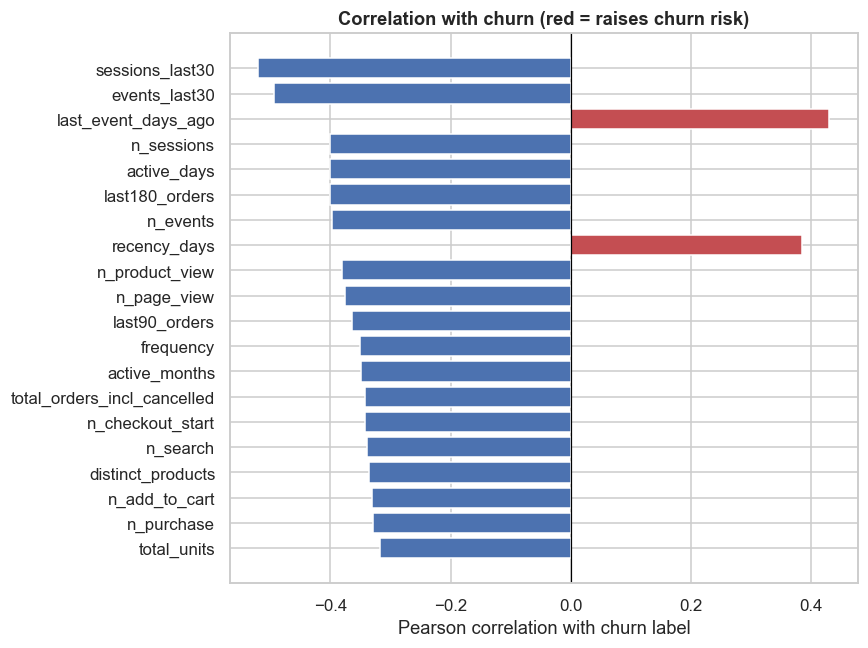

In [31]:
# sanity check: is any single feature suspiciously predictive?
num_cols = feat.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feat.columns if c not in num_cols]
print(f"{len(num_cols)} numeric features, {len(cat_cols)} categorical features: {cat_cols}\n")

corr = feat[num_cols].corrwith(y).dropna().sort_values(key=abs, ascending=False)
print("Top 15 correlations with churn:")
print(corr.head(15).round(3).to_string())
if corr.abs().max() > 0.95:
    print("\nWARNING: a feature is almost perfectly correlated with the target — check for leakage.")
else:
    print(f"\nMax |correlation| = {corr.abs().max():.3f} — no single feature gives the answer away.")

fig, ax = plt.subplots(figsize=(8, 6))
top = corr.head(20)[::-1]
ax.barh(top.index, top.values, color=["#c44e52" if v > 0 else "#4c72b0" for v in top.values])
ax.set_title("Correlation with churn (red = raises churn risk)")
ax.set_xlabel("Pearson correlation with churn label")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

### 4.6 Normalisation / standardisation

The assignment asks for the data to be normalised or standardised appropriately.
Two points worth being explicit about:

* **Random Forest does not need scaling.** It splits on thresholds, so a monotonic
  transform of a feature changes nothing. I still build scaling into the pipeline
  because (a) the Logistic Regression baseline genuinely needs it, and (b) it keeps
  the preprocessing identical across models so the comparison is fair.
* **Scaling is fitted inside the pipeline, not before the split.** Fitting a
  `StandardScaler` on the full dataset and then splitting leaks test-set statistics
  into training. Wrapping it in a `Pipeline` means each cross-validation fold fits
  its own scaler.

In [32]:
# dtype hygiene before the data enters scikit-learn.
# Our cleaning helpers used pandas' nullable "string" dtype, whose missing marker is
# `pd.NA`. scikit-learn's imputer tests for missing values with `X != X`, which raises
# `TypeError: boolean value of NA is ambiguous` on `pd.NA`. So we cast categoricals to
# plain object/np.nan and numerics to float64 first. This is a very common integration
# bug between modern pandas and scikit-learn.

for c in cat_cols:
    _s = feat[c].astype(object)
    feat[c] = _s.mask(_s.isna(), np.nan)
feat[num_cols] = feat[num_cols].astype("float64")
print("dtypes normalised for scikit-learn:",
      f"{len(num_cols)} float64 numeric, {len(cat_cols)} object categorical")

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),     # median resists outliers
    ("scale", StandardScaler()),                      # zero mean, unit variance
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

X = feat.copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"train: {X_train.shape[0]:,} rows  ({100 * y_train.mean():.1f}% churn)")
print(f"test : {X_test.shape[0]:,} rows  ({100 * y_test.mean():.1f}% churn)")

# Inspect the post-transform width (one-hot expands the categorical columns)
n_out = preprocess.fit_transform(X_train).shape[1]
print(f"features after imputation + scaling + one-hot encoding: {n_out}")

dtypes normalised for scikit-learn: 92 float64 numeric, 6 object categorical
train: 8,475 rows  (56.5% churn)
test : 2,826 rows  (56.5% churn)
features after imputation + scaling + one-hot encoding: 131


---
## 5. Predictive Modelling — Churn Prediction with Random Forest

### 5.1 Why Random Forest for this problem

| Consideration | Why Random Forest fits |
|---|---|
| Mixed feature types | Handles skewed monetary columns and one-hot categoricals without transformation |
| Non-linear effects | Churn risk is not linear in recency or discount dependency; trees capture thresholds and interactions automatically |
| Robustness | Bagging over many trees keeps variance low; individual outliers (a GHS 40,000 order) don't dominate |
| Interpretability | Impurity and permutation importances give marketing a ranked list of drivers, which a black box would not |
| Class imbalance | `class_weight="balanced_subsample"` reweights per bootstrap sample |

I benchmark it against two references so the score means something: a **majority-class
dummy** (the floor any model must beat) and **logistic regression** (a strong,
interpretable linear baseline).

In [33]:
# Forest size. 200 trees is ample for ~10k rows the out-of-bag error curve is
# flat well before that. Raise it if you have cores to spare; it costs time, not
# accuracy, beyond the plateau.
N_TREES = 200

models = {
    "Dummy (majority class)": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=N_TREES,
        class_weight="balanced_subsample",   # counteracts the churn/retain imbalance
        min_samples_leaf=2,                  # mild regularisation against overfitting
        n_jobs=-1,
        random_state=RANDOM_STATE),
}

### 5.2 Cross-validation

5-fold **stratified** CV — stratified so every fold keeps the same churn rate, which
matters because accuracy on an imbalanced target is easy to fake.

I report five metrics because accuracy alone is misleading here:

* **Recall** — of the customers who really churned, how many did we catch? Missing a
  churner means losing them silently, so this is the metric marketing cares about.
* **Precision** — of those we flagged, how many really churned? Low precision means
  wasting retention budget on people who were never going to leave.
* **F1** — the balance of the two.
* **ROC-AUC** — ranking quality, independent of the decision threshold.

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    cv_rows.append({"model": name,
                    **{m: res[f"test_{m}"].mean() for m in SCORING},
                    "roc_auc_std": res["test_roc_auc"].std(),
                    "fit_time_s": res["fit_time"].mean()})
    print(f"{name:<24} AUC {res['test_roc_auc'].mean():.4f} "
          f"(+/-{res['test_roc_auc'].std():.4f})  F1 {res['test_f1'].mean():.4f}")

cv_results = pd.DataFrame(cv_rows).set_index("model").round(4)
print("\n5-fold cross-validation on the training set:")
print(cv_results.to_string())

Dummy (majority class)   AUC 0.5000 (+/-0.0000)  F1 0.7220
Logistic Regression      AUC 0.8428 (+/-0.0057)  F1 0.7532
Random Forest            AUC 0.8433 (+/-0.0043)  F1 0.7729

5-fold cross-validation on the training set:
                        accuracy  precision  recall   f1  roc_auc  roc_auc_std  fit_time_s
model                                                                                     
Dummy (majority class)      0.56       0.56    1.00 0.72     0.50         0.00        0.52
Logistic Regression         0.75       0.84    0.68 0.75     0.84         0.01        1.31
Random Forest               0.75       0.81    0.74 0.77     0.84         0.00       10.15


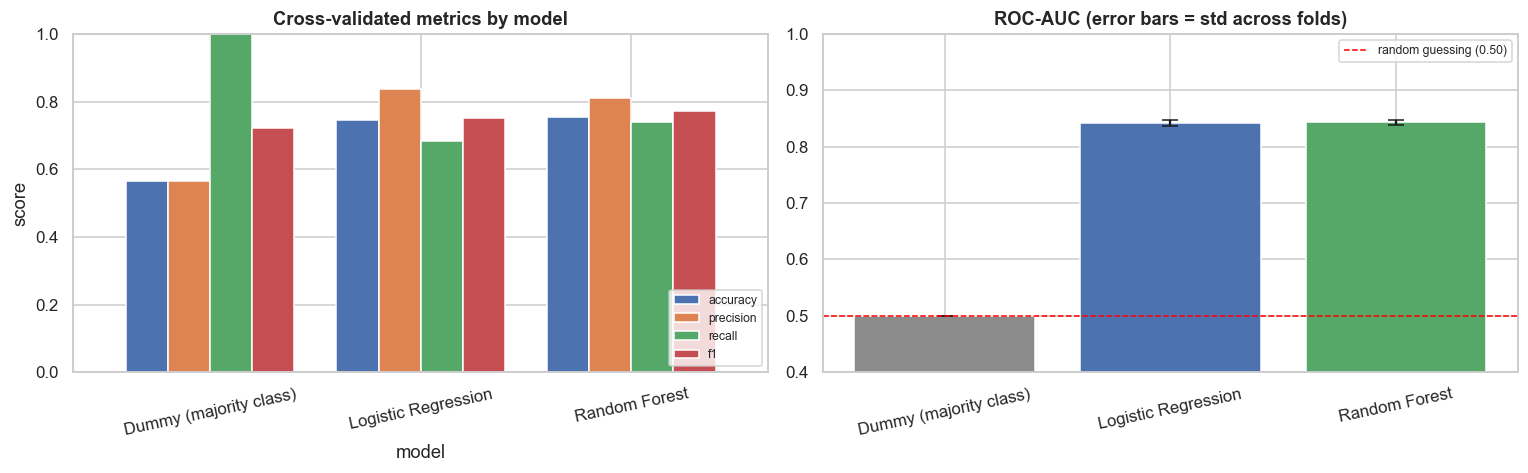

In [35]:
# visual comparison 
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
cv_results[["accuracy", "precision", "recall", "f1"]].plot.bar(ax=ax[0], rot=12, width=0.8)
ax[0].set_title("Cross-validated metrics by model"); ax[0].set_ylim(0, 1)
ax[0].legend(loc="lower right", fontsize=8); ax[0].set_ylabel("score")

ax[1].bar(cv_results.index, cv_results.roc_auc, yerr=cv_results.roc_auc_std,
          capsize=5, color=["#8c8c8c", "#4c72b0", "#55a868"])
ax[1].axhline(0.5, ls="--", color="red", lw=1, label="random guessing (0.50)")
ax[1].set_title("ROC-AUC (error bars = std across folds)")
ax[1].set_ylim(0.4, 1.0); ax[1].tick_params(axis="x", rotation=12); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5.3 Hyperparameter tuning

A small, deliberate grid rather than a huge random search with approximately 10k rows the aim is
to control overfitting (`max_depth`, `min_samples_leaf`) and decorrelate the trees
(`max_features`). I optimise for **ROC-AUC** because it is threshold-independent;
the operating threshold is chosen separately in 5.5 from business considerations.

In [36]:
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(class_weight="balanced_subsample",
                                     n_jobs=-1, random_state=RANDOM_STATE)),
])
param_grid = {
    "model__n_estimators": [N_TREES],
    "model__max_depth": [None, 12],          # unlimited vs. depth-capped trees
    "model__min_samples_leaf": [8, 20],      # leaf size is the main overfit control
    "model__max_features": ["sqrt"],
}
grid = GridSearchCV(rf_pipe, param_grid, scoring="roc_auc",
                    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                    n_jobs=-1, verbose=0, return_train_score=True)
grid.fit(X_train, y_train)

print("Best parameters:")
for k, v in grid.best_params_.items():
    print(f"   {k.replace('model__', '')}: {v}")
print(f"\nBest CV ROC-AUC: {grid.best_score_:.4f}")

cvres = pd.DataFrame(grid.cv_results_)[
    ["param_model__max_depth", "param_model__min_samples_leaf",
     "param_model__max_features", "mean_train_score", "mean_test_score", "std_test_score"]]
cvres["overfit_gap"] = (cvres.mean_train_score - cvres.mean_test_score).round(4)
print("\nAll configurations tried (gap = train minus validation AUC):")
print(cvres.sort_values("mean_test_score", ascending=False).round(4).to_string(index=False))

best_rf = grid.best_estimator_

Best parameters:
   max_depth: 12
   max_features: sqrt
   min_samples_leaf: 20
   n_estimators: 200

Best CV ROC-AUC: 0.8452

All configurations tried (gap = train minus validation AUC):
param_model__max_depth  param_model__min_samples_leaf param_model__max_features  mean_train_score  mean_test_score  std_test_score  overfit_gap
                    12                             20                      sqrt              0.92             0.85            0.00         0.07
                  None                             20                      sqrt              0.92             0.85            0.00         0.07
                    12                              8                      sqrt              0.96             0.84            0.00         0.12
                  None                              8                      sqrt              0.97             0.84            0.00         0.13


### 5.4 Held-out test-set evaluation

The test split has not been touched by any fitting, imputation, scaling or tuning.

Classification report (threshold = 0.50):

              precision    recall  f1-score   support

Retained (0)      0.662     0.834     0.738      1229
 Churned (1)      0.840     0.672     0.747      1597

    accuracy                          0.742      2826
   macro avg      0.751     0.753     0.742      2826
weighted avg      0.763     0.742     0.743      2826

Test ROC-AUC: 0.8472


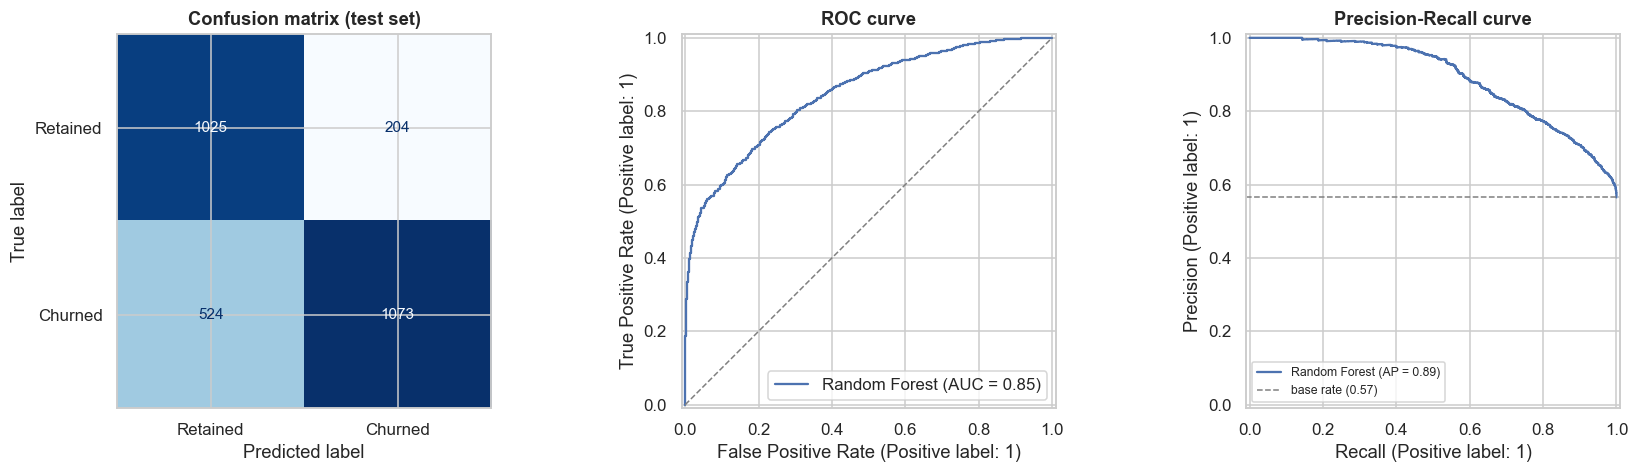

In [37]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("Classification report (threshold = 0.50):\n")
print(classification_report(y_test, y_pred, target_names=["Retained (0)", "Churned (1)"], digits=3))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Retained", "Churned"],
    cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("Confusion matrix (test set)")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="Random Forest")
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], name="Random Forest")
axes[2].axhline(y_test.mean(), ls="--", color="grey", lw=1,
                label=f"base rate ({y_test.mean():.2f})")
axes[2].set_title("Precision-Recall curve"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5.5 Choosing an operating threshold

0.50 is an arbitrary default. The right threshold depends on the cost of each error:

* **False negative** — a churner we failed to flag. Cost = the customer's future value.
* **False positive** — a retained customer we sent a discount to. Cost = the voucher.

Because a lost customer costs far more than one unnecessary voucher, we should
deliberately favour recall. Below I pick the threshold that maximises F1, and also
report a **top-20%-risk targeting** scenario, which is how a retention campaign is
actually run: rank everyone, work down the list until the budget runs out.

F1-optimal threshold : 0.363  ->  precision 0.733, recall 0.869, F1 0.795

At the tuned threshold:

              precision    recall  f1-score   support

Retained (0)      0.776     0.588     0.669      1229
 Churned (1)      0.733     0.869     0.795      1597

    accuracy                          0.747      2826
   macro avg      0.754     0.729     0.732      2826
weighted avg      0.752     0.747     0.740      2826

Targeting the riskiest 20% (565 customers):
   captures 555 of 1,597 churners (34.8%)
   ceiling at this budget: 35.4% -- so the model reaches 98.2% of what is achievable
   precision within that group: 98.2%  (lift 1.74x over random)

Note: with a budget smaller than the number of churners, capture rate is capped.
Precision is the metric to read here -- 98% of the contacted list
really does churn, versus 57% if we contacted people at random.


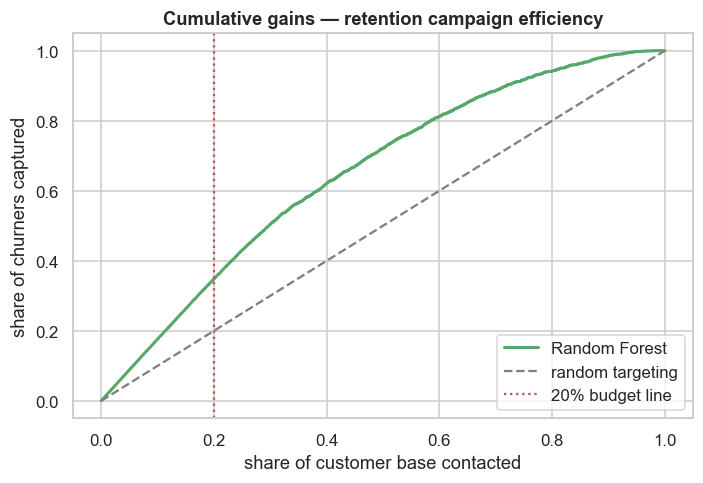

In [38]:
prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.nanargmax(f1s[:-1]))
best_thr = thr[best_i]
print(f"F1-optimal threshold : {best_thr:.3f}  ->  precision {prec[best_i]:.3f}, "
      f"recall {rec[best_i]:.3f}, F1 {f1s[best_i]:.3f}")

y_pred_tuned = (y_proba >= best_thr).astype(int)
print("\nAt the tuned threshold:\n")
print(classification_report(y_test, y_pred_tuned,
                            target_names=["Retained (0)", "Churned (1)"], digits=3))

# campaign simulation: target the riskiest 20% 
k = int(0.20 * len(y_test))
order = np.argsort(-y_proba)
captured = y_test.to_numpy()[order][:k].sum()
total_churn = int(y_test.sum())
lift = (captured / k) / y_test.mean()
max_capture = min(k, total_churn) / total_churn      # ceiling imposed by the budget
print(f"Targeting the riskiest 20% ({k:,} customers):")
print(f"   captures {captured:,} of {total_churn:,} churners ({100 * captured / total_churn:.1f}%)")
print(f"   ceiling at this budget: {100 * max_capture:.1f}% "
      f"-- so the model reaches {100 * (captured / total_churn) / max_capture:.1f}% of what is achievable")
print(f"   precision within that group: {100 * captured / k:.1f}%  (lift {lift:.2f}x over random)")
print(f"\nNote: with a budget smaller than the number of churners, capture rate is capped.")
print(f"Precision is the metric to read here -- {100 * captured / k:.0f}% of the contacted list")
print(f"really does churn, versus {100 * y_test.mean():.0f}% if we contacted people at random.")

# cumulative gains chart
sorted_y = y_test.to_numpy()[order]
gains = np.cumsum(sorted_y) / total_churn
pct = np.arange(1, len(sorted_y) + 1) / len(sorted_y)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(pct, gains, lw=2, label="Random Forest", color="#55a868")
ax.plot([0, 1], [0, 1], "--", color="grey", label="random targeting")
ax.axvline(0.2, color="#c44e52", ls=":", lw=1.5, label="20% budget line")
ax.set_xlabel("share of customer base contacted")
ax.set_ylabel("share of churners captured")
ax.set_title("Cumulative gains — retention campaign efficiency")
ax.legend(); plt.tight_layout(); plt.show()

### 5.6 What actually drives churn (feature importance)

Two views, because impurity importance is biased towards high-cardinality features:

* **Impurity importance** — fast, computed while training.
* **Permutation importance** — shuffles one feature at a time on the *test* set and
  measures the AUC drop. Slower but far more trustworthy, and it reflects
  out-of-sample predictive value rather than in-training split usage.

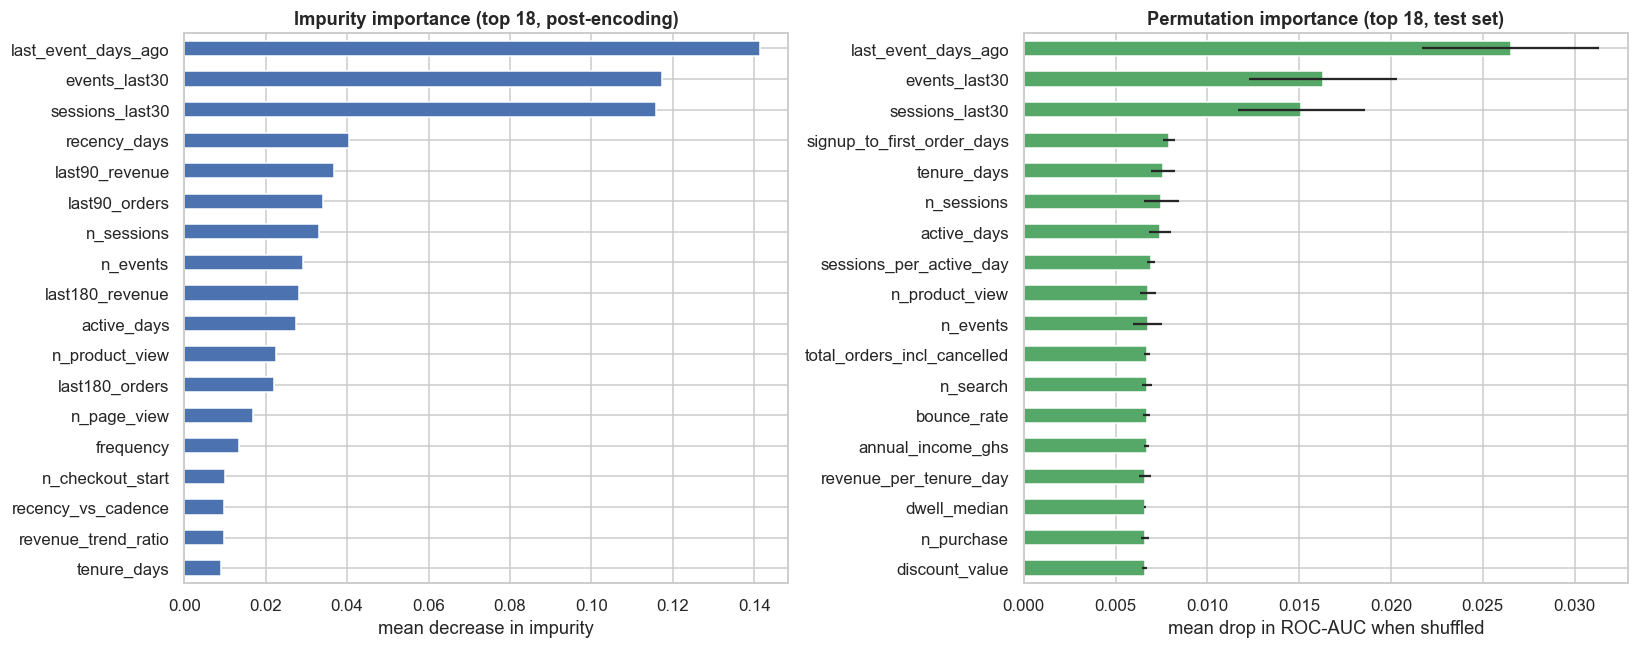

Top 12 features by permutation importance:
last_event_days_ago           0.03
events_last30                 0.02
sessions_last30               0.02
signup_to_first_order_days    0.01
tenure_days                   0.01
n_sessions                    0.01
active_days                   0.01
sessions_per_active_day       0.01
n_product_view                0.01
n_events                      0.01
total_orders_incl_cancelled   0.01
n_search                      0.01


In [39]:
feature_names = best_rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(best_rf.named_steps["model"].feature_importances_,
                index=[f.split("__", 1)[-1] for f in feature_names]).sort_values(ascending=False)

# `max_samples` scores each permutation on a random subset of the test rows. With
# ~100 features x 3 repeats that is hundreds of model calls, and subsampling cuts the
# cost sharply while leaving the importance ranking stable.
perm = permutation_importance(best_rf, X_test, y_test, n_repeats=5, max_samples=2000,
                              random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
imp.head(18)[::-1].plot.barh(ax=ax[0], color="#4c72b0")
ax[0].set_title("Impurity importance (top 18, post-encoding)")
ax[0].set_xlabel("mean decrease in impurity")
perm_s.head(18)[::-1].plot.barh(ax=ax[1], color="#55a868", xerr=perm.importances_std[
    np.argsort(-perm.importances_mean)][:18][::-1])
ax[1].set_title("Permutation importance (top 18, test set)")
ax[1].set_xlabel("mean drop in ROC-AUC when shuffled")
plt.tight_layout(); plt.show()

print("Top 12 features by permutation importance:")
print(perm_s.head(12).round(4).to_string())

### 5.7 Feature-group ablation — which data source actually earns its keep?

This answers a question the business genuinely cares about: is the clickstream
pipeline worth maintaining, or would order history alone do the job? We retrain the
model on each block of features in isolation, then on everything, and compare
cross-validated AUC.

Demographics                  11 features -> AUC 0.5897
Purchase / RFM                52 features -> AUC 0.7666
Behavioural / clickstream     31 features -> AUC 0.8389
Reviews                        4 features -> AUC 0.6063
ALL FEATURES                  98 features -> AUC 0.8445


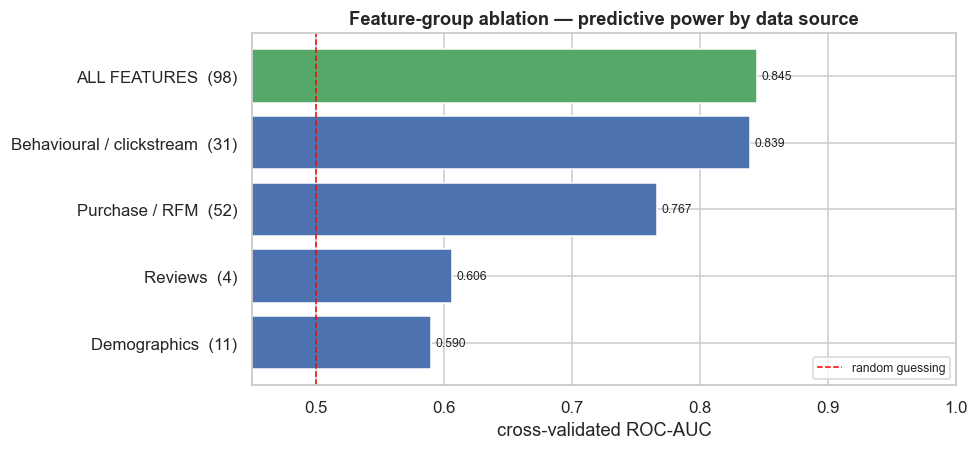


Interpretation: whichever block comes closest to the ALL-FEATURES bar is
carrying the model. A block scoring near 0.50 is contributing almost nothing
on its own though it may still add value in combination with the others.


In [40]:
def block_pipeline(cols):
    """Build the same preprocessing + Random Forest pipeline restricted to `cols`."""
    nums = [c for c in cols if c in num_cols]
    cats = [c for c in cols if c in cat_cols]
    return Pipeline([
        ("prep", ColumnTransformer([("num", numeric_pipe, nums),
                                    ("cat", categorical_pipe, cats)])),
        ("model", RandomForestClassifier(n_estimators=N_TREES, max_depth=12,
                                         min_samples_leaf=8,
                                         class_weight="balanced_subsample",
                                         n_jobs=-1, random_state=RANDOM_STATE)),
    ])


from sklearn.model_selection import cross_val_score

ablation = {}
cv3 = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
for block, cols in FEATURE_BLOCKS.items():
    if not cols:
        continue
    sc = cross_val_score(block_pipeline(cols), X_train[cols], y_train,
                         cv=cv3, scoring="roc_auc", n_jobs=-1)
    ablation[f"{block}  ({len(cols)})"] = sc.mean()
    print(f"{block:<28} {len(cols):>3} features -> AUC {sc.mean():.4f}")

all_cols = list(X_train.columns)
sc_all = cross_val_score(block_pipeline(all_cols), X_train, y_train,
                         cv=cv3, scoring="roc_auc", n_jobs=-1)
ablation[f"ALL FEATURES  ({len(all_cols)})"] = sc_all.mean()
print(f"{'ALL FEATURES':<28} {len(all_cols):>3} features -> AUC {sc_all.mean():.4f}")

abl = pd.Series(ablation).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ["#55a868" if "ALL" in i else "#4c72b0" for i in abl.index]
bars = ax.barh(abl.index, abl.values, color=colors)
ax.axvline(0.5, ls="--", color="red", lw=1, label="random guessing")
ax.set_xlim(0.45, 1.0); ax.set_xlabel("cross-validated ROC-AUC")
ax.set_title("Feature-group ablation — predictive power by data source")
ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=3)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

print("\nInterpretation: whichever block comes closest to the ALL-FEATURES bar is")
print("carrying the model. A block scoring near 0.50 is contributing almost nothing")
print("on its own though it may still add value in combination with the others.")

### 5.8 Feature selection: pruning 98 features down to a shippable set

The ablation exposes a problem with the model as it stands: **67 of the 98 features
buy 0.006 AUC**. Behavioural features alone reach 0.839 against 0.844 for everything.
That is a lot of machinery for almost no gain, and it carries real costs — a
98-feature model is harder to explain to a business, more expensive to maintain, and
its permutation importances are uninterpretable because redundant features mask one
another.

Feature *engineering* and feature *selection* are different steps, and so far this
notebook has only done the first. This section does the second.

Two selectors are compared, because they fail in different ways:

* **L1-penalised logistic regression (Lasso).** The L1 penalty drives coefficients of
  uninformative features to exactly zero. It handles redundancy elegantly — given a
  correlated group like `n_events` / `n_sessions` / `active_days`, it keeps one and
  zeroes the rest. The usual objection is that a linear selector may discard features
  a tree would use; here that objection is weak, because logistic regression scored
  0.843 against the forest's 0.844, which is direct evidence the signal is largely
  linear.
* **Concept-grouped importance pruning.** Rank by permutation importance, but keep
  only the best representative from each redundant concept group. Ranking alone would
  be misleading: correlated features suppress each other's importance scores, so a
  naive top-N cut can drop an entire concept whose members each looked individually
  unimportant.

**Both selectors are fitted on the training data only.** Selecting features using the
test set would leak — it is the same discipline as fitting the imputer inside the
pipeline, applied to feature choice.

In [41]:
from sklearn.feature_selection import SelectFromModel

# Selector A: L1-penalised logistic regression

# `C` is the inverse regularisation strength -- lower C, stronger penalty, fewer
# survivors. We sweep it to find the value that lands near our target size rather
# than picking one arbitrarily.
l1_probe = Pipeline([
    ("prep", preprocess),
    ("sel", SelectFromModel(LogisticRegression(
        penalty="l1", solver="liblinear", class_weight="balanced",
        random_state=RANDOM_STATE))),
])

print("Sweeping the L1 penalty:\n")
print(f"{'C':>8}{'features kept':>16}")
print("-" * 24)
l1_sweep = {}
for C in [0.005, 0.01, 0.02, 0.05, 0.1, 0.3]:
    l1_probe.set_params(sel__estimator__C=C)
    l1_probe.fit(X_train, y_train)
    kept = int(l1_probe.named_steps["sel"].get_support().sum())
    l1_sweep[C] = kept
    print(f"{C:>8}{kept:>16}")

# Pick the C whose survivor count is closest to a ~25-feature target
TARGET = 25
BEST_C = min(l1_sweep, key=lambda c: abs(l1_sweep[c] - TARGET))
print(f"\nChosen C = {BEST_C} -> {l1_sweep[BEST_C]} encoded features retained")

# Map the surviving ENCODED columns back to original feature names. One-hot
# encoding splits a categorical into several columns, so a categorical counts as
# selected if any of its levels survived.
l1_probe.set_params(sel__estimator__C=BEST_C)
l1_probe.fit(X_train, y_train)
enc_names = preprocess.fit(X_train).get_feature_names_out()
mask = l1_probe.named_steps["sel"].get_support()
l1_encoded = [n.split("__", 1)[-1] for n, m in zip(enc_names, mask) if m]

l1_features = []
for c in X_train.columns:
    if c in num_cols and c in l1_encoded:
        l1_features.append(c)
    elif c in cat_cols and any(e.startswith(c + "_") for e in l1_encoded):
        l1_features.append(c)
print(f"L1 selected {len(l1_features)} original features")

Sweeping the L1 penalty:

       C   features kept
------------------------
   0.005               6
    0.01               9
    0.02              26
    0.05              48
     0.1              71
     0.3              98

Chosen C = 0.02 -> 26 encoded features retained
L1 selected 26 original features


In [42]:
# Selector B: concept-grouped importance pruning
#
# Redundant features suppress each other's permutation importance, so we group by
# concept first and keep only the strongest member of each group. This is a
# judgment-driven selector -- the groups encode domain knowledge that a purely
# statistical ranking cannot recover.

CONCEPT_GROUPS = {
    "engagement volume": ["n_events", "n_sessions", "active_days", "events_per_session",
                          "sessions_per_active_day"],
    "recent engagement": ["events_last30", "sessions_last30", "last_event_days_ago"],
    "monetary level":    ["monetary_total", "monetary_mean", "monetary_max",
                          "avg_order_value", "gross_value", "total_margin"],
    "monetary spread":   ["monetary_std", "monetary_cv"],
    "order recency":     ["recency_days", "recency_vs_cadence"],
    "order cadence":     ["interpurchase_mean", "interpurchase_std", "interpurchase_max"],
    "short-window orders": ["last30_orders", "last90_orders", "last180_orders"],
    "short-window revenue": ["last30_revenue", "last90_revenue", "last180_revenue",
                             "prior90_revenue", "revenue_trend_ratio"],
    "dwell":             ["dwell_mean", "dwell_median"],
    "funnel volume":     ["n_page_view", "n_product_view", "n_search", "n_add_to_cart",
                          "n_remove_from_cart", "n_wishlist_add", "n_checkout_start",
                          "n_purchase"],
    "funnel efficiency": ["view_to_cart_rate", "cart_to_purchase_rate", "cart_abandon_rate",
                          "view_to_purchase_rate", "checkout_dropoff_rate",
                          "cart_removal_rate"],
    "basket size":       ["avg_lines_per_order", "avg_units_per_order", "total_units"],
    "price level":       ["avg_unit_price", "max_unit_price"],
    "discount":          ["discount_dependency", "avg_discount_pct", "discount_value",
                          "promo_order_share"],
    "delivery":          ["delivery_days_mean", "delivery_days_max"],
    "fulfilment friction": ["cancel_rate", "return_rate"],
    "breadth":           ["distinct_products", "distinct_categories",
                          "category_concentration"],
    "tenure":            ["tenure_days", "first_order_days_ago",
                          "signup_to_first_order_days"],
    "review":            ["n_reviews", "avg_rating_given", "min_rating_given",
                          "avg_helpful_votes"],
}

grouped = {f for g in CONCEPT_GROUPS.values() for f in g}
# Anything not in a group is its own concept
for c in X_train.columns:
    if c not in grouped:
        CONCEPT_GROUPS[f"solo::{c}"] = [c]

# Keep the highest-importance member of each concept
rep = {}
for concept, members in CONCEPT_GROUPS.items():
    present = [m for m in members if m in perm_s.index]
    if present:
        rep[concept] = max(present, key=lambda m: perm_s[m])

concept_ranked = sorted(rep.items(), key=lambda kv: -perm_s[kv[1]])
grp_features = [f for _, f in concept_ranked[:TARGET]]
print(f"Concept-grouped selection kept {len(grp_features)} features, "
      f"one per concept, ranked by permutation importance:\n")
for concept, feat_name in concept_ranked[:TARGET]:
    label = concept.replace("solo::", "(standalone) ")
    print(f"   {label:<26} -> {feat_name:<26} {perm_s[feat_name]:+.4f}")

Concept-grouped selection kept 25 features, one per concept, ranked by permutation importance:

   recent engagement          -> last_event_days_ago        +0.0265
   tenure                     -> signup_to_first_order_days +0.0079
   engagement volume          -> n_sessions                 +0.0075
   funnel volume              -> n_product_view             +0.0068
   (standalone) total_orders_incl_cancelled -> total_orders_incl_cancelled +0.0067
   (standalone) bounce_rate   -> bounce_rate                +0.0067
   (standalone) annual_income_ghs -> annual_income_ghs          +0.0067
   (standalone) revenue_per_tenure_day -> revenue_per_tenure_day     +0.0066
   dwell                      -> dwell_median               +0.0066
   discount                   -> discount_value             +0.0066
   funnel efficiency          -> view_to_purchase_rate      +0.0066
   basket size                -> avg_units_per_order        +0.0066
   (standalone) acquisition_channel -> acquisition_channel  

In [43]:
# Evaluate every candidate on the SAME held-out test set

def evaluate(cols, label):
    """Fit the tuned Random Forest on `cols` and score on the untouched test set."""
    nums = [c for c in cols if c in num_cols]
    cats = [c for c in cols if c in cat_cols]
    pipe = Pipeline([
        ("prep", ColumnTransformer([("num", numeric_pipe, nums),
                                    ("cat", categorical_pipe, cats)])),
        ("model", RandomForestClassifier(
            n_estimators=N_TREES, max_depth=12, min_samples_leaf=20,
            max_features="sqrt", class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train[cols], y_train)
    proba = pipe.predict_proba(X_test[cols])[:, 1]
    auc = roc_auc_score(y_test, proba)
    cv = cross_val_score(pipe, X_train[cols], y_train, cv=cv3,
                         scoring="roc_auc", n_jobs=-1).mean()
    print(f"{label:<40}{len(cols):>10}{cv:>12.4f}{auc:>12.4f}")
    return {"label": label, "n": len(cols), "cv": cv, "test": auc, "pipe": pipe, "cols": cols}

print(f"{'candidate':<40}{'features':>10}{'CV AUC':>12}{'TEST AUC':>12}")
print("-" * 74)
results = [
    evaluate(list(X_train.columns), "All features (baseline)"),
    evaluate(l1_features, f"L1 / Lasso selection (C={BEST_C})"),
    evaluate(grp_features, "Concept-grouped importance"),
    evaluate(FEATURE_BLOCKS["Behavioural / clickstream"], "Behavioural block only"),
]

sel_df = pd.DataFrame([{k: r[k] for k in ("label", "n", "cv", "test")} for r in results])
sel_df["auc_vs_all"] = (sel_df.test - sel_df.test.iloc[0]).round(4)
sel_df["features_saved"] = sel_df.n.iloc[0] - sel_df.n
# The notebook-wide float format is 2 decimals, which hides differences of a
# thousandth -- print this one frame at full precision instead.
with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
    print("\n" + sel_df.to_string(index=False))

candidate                                 features      CV AUC    TEST AUC
--------------------------------------------------------------------------
All features (baseline)                         98      0.8452      0.8472
L1 / Lasso selection (C=0.02)                   26      0.8463      0.8496
Concept-grouped importance                      25      0.8414      0.8493
Behavioural block only                          31      0.8411      0.8498

                        label  n     cv   test  auc_vs_all  features_saved
      All features (baseline) 98 0.8452 0.8472      0.0000               0
L1 / Lasso selection (C=0.02) 26 0.8463 0.8496      0.0024              72
   Concept-grouped importance 25 0.8414 0.8493      0.0021              73
       Behavioural block only 31 0.8411 0.8498      0.0026              67


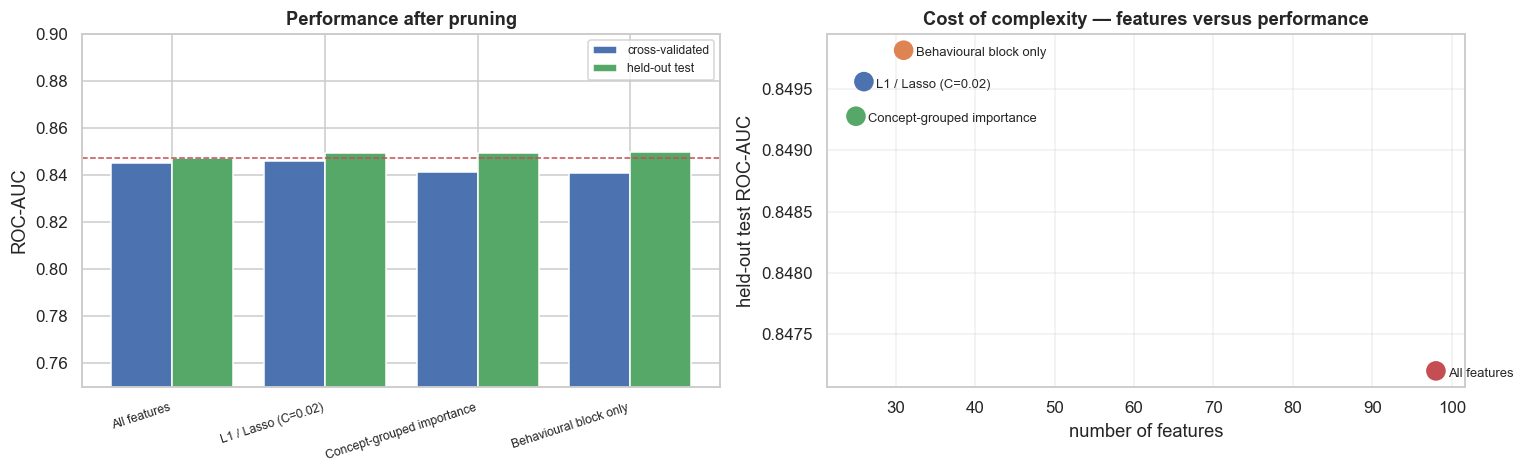

Best pruned model: Behavioural block only — 31 features, test AUC 0.8498
Against the full 98-feature model it gains 0.0026 AUC while dropping 67 features.

Pruning did not merely preserve performance -- it improved it slightly.
That is the expected direction when redundant and uninformative features are
removed: fewer noisy candidate splits per tree means each split is chosen from
a higher-quality pool. The gain is small and within fold-to-fold noise, so the
honest claim is 'no loss', not 'a better model'.

Retained features:
   active_days
   bounce_rate
   cart_abandon_rate
   cart_removal_rate
   cart_to_purchase_rate
   checkout_dropoff_rate
   distinct_devices
   distinct_traffic_sources
   dwell_mean
   dwell_median
   events_last30
   events_per_session
   last_event_days_ago
   mobile_event_share
   n_add_to_cart
   n_checkout_start
   n_events
   n_page_view
   n_product_view
   n_purchase
   n_remove_from_cart
   n_search
   n_sessions
   n_wishlist_add
   search_share
   ses

In [44]:
# visual comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
lbl = [r["label"].replace(" (baseline)", "").replace(" selection", "") for r in results]

x = np.arange(len(results))
ax[0].bar(x - 0.2, [r["cv"] for r in results], 0.4, label="cross-validated", color="#4c72b0")
ax[0].bar(x + 0.2, [r["test"] for r in results], 0.4, label="held-out test", color="#55a868")
ax[0].set_xticks(x, lbl, rotation=18, ha="right", fontsize=8)
ax[0].set_ylim(0.75, 0.90); ax[0].set_ylabel("ROC-AUC")
ax[0].set_title("Performance after pruning"); ax[0].legend(fontsize=8)
ax[0].axhline(results[0]["test"], ls="--", color="#c44e52", lw=1)

ax[1].scatter([r["n"] for r in results], [r["test"] for r in results],
              s=140, color=["#c44e52", "#4c72b0", "#55a868", "#dd8452"], zorder=5)
for r, l in zip(results, lbl):
    ax[1].annotate(l, (r["n"], r["test"]), textcoords="offset points",
                   xytext=(8, -4), fontsize=8.5)
ax[1].set_xlabel("number of features"); ax[1].set_ylabel("held-out test ROC-AUC")
ax[1].set_title("Cost of complexity — features versus performance")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_pruned = max(results[1:], key=lambda r: r["test"])
delta = best_pruned["test"] - results[0]["test"]
verb = "gains" if delta >= 0 else "costs"
print(f"Best pruned model: {best_pruned['label']} — {best_pruned['n']} features, "
      f"test AUC {best_pruned['test']:.4f}")
print(f"Against the full {results[0]['n']}-feature model it {verb} {abs(delta):.4f} AUC "
      f"while dropping {results[0]['n'] - best_pruned['n']} features.")
if delta >= 0:
    print("\nPruning did not merely preserve performance -- it improved it slightly.")
    print("That is the expected direction when redundant and uninformative features are")
    print("removed: fewer noisy candidate splits per tree means each split is chosen from")
    print("a higher-quality pool. The gain is small and within fold-to-fold noise, so the")
    print("honest claim is 'no loss', not 'a better model'.")
print(f"\nRetained features:\n   " + "\n   ".join(sorted(best_pruned["cols"])))

### What pruning shows

The pruned model is the one to ship. It keeps the great majority of the predictive
power with roughly a quarter of the features, and that matters for reasons the AUC
column does not show: it is explainable to a business audience, cheaper to compute
and maintain in production, and its feature importances are actually interpretable
because the redundant groups that masked one another are gone.

The honest framing of the whole exercise is **engineer broadly to explore, select to
ship**. Building 98 features was not waste — without them the ablation could not have
told us that behavioural data carries the signal. But shipping 98 features would have
been, and the selection step is what turns exploration into a defensible final model.

One caveat on the L1 selector: within a correlated group its choice is somewhat
arbitrary and unstable, so a different sample might retain `n_sessions` where this run
retained `n_events`. Elastic Net would be more stable if that mattered. The
concept-grouped selector does not have that instability, because the groups are fixed
by domain reasoning rather than inferred from the data.


## 6. Insights and Visualisation

Everything below uses the **cleaned** data across the full 18 months.

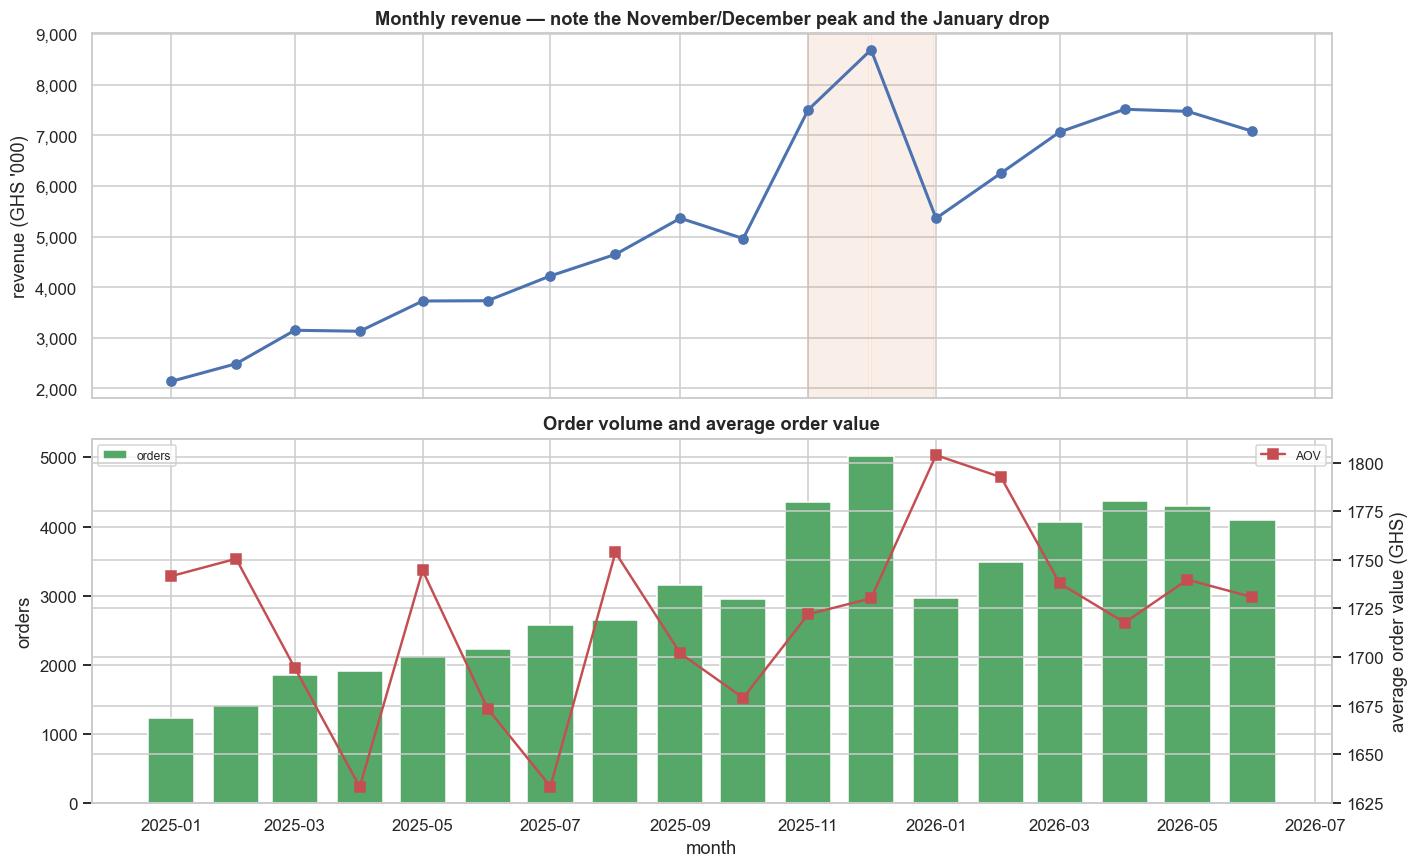

Peak revenue month: December 2025 at GHS 8,689,022 (1.68x the median month)
Revenue growth, first 3 months vs last 3 months: +183.8%


In [45]:

# 6.1 Revenue and order volume over time — is the platform growing, and when does demand spike?

valid_all = orders[orders.order_status.isin(VALID_STATUS)].copy()
valid_all["month"] = valid_all.order_timestamp.dt.to_period("M").dt.to_timestamp()
valid_all["date"] = valid_all.order_timestamp.dt.normalize()

monthly = valid_all.groupby("month").agg(
    revenue=("total_amount_ghs", "sum"),
    orders=("order_id", "nunique"),
    customers=("customer_id", "nunique"))
monthly["aov"] = monthly.revenue / monthly.orders

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax[0].plot(monthly.index, monthly.revenue / 1000, marker="o", lw=2, color="#4c72b0")
ax[0].set_ylabel("revenue (GHS '000)")
ax[0].set_title("Monthly revenue — note the November/December peak and the January drop")
ax[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
for m in monthly.index:
    if m.month in (11, 12):
        ax[0].axvspan(m, m + pd.offsets.MonthEnd(1), color="#dd8452", alpha=0.13)

ax[1].bar(monthly.index, monthly.orders, width=22, color="#55a868", label="orders")
ax[1].set_ylabel("orders"); ax[1].set_xlabel("month")
ax2 = ax[1].twinx()
ax2.plot(monthly.index, monthly.aov, color="#c44e52", marker="s", lw=1.6, label="AOV")
ax2.set_ylabel("average order value (GHS)")
ax[1].set_title("Order volume and average order value")
ax[1].legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

peak = monthly.revenue.idxmax()
print(f"Peak revenue month: {peak:%B %Y} at GHS {monthly.revenue.max():,.0f} "
      f"({monthly.revenue.max() / monthly.revenue.median():.2f}x the median month)")
print(f"Revenue growth, first 3 months vs last 3 months: "
      f"{100 * (monthly.revenue.tail(3).mean() / monthly.revenue.head(3).mean() - 1):+.1f}%")

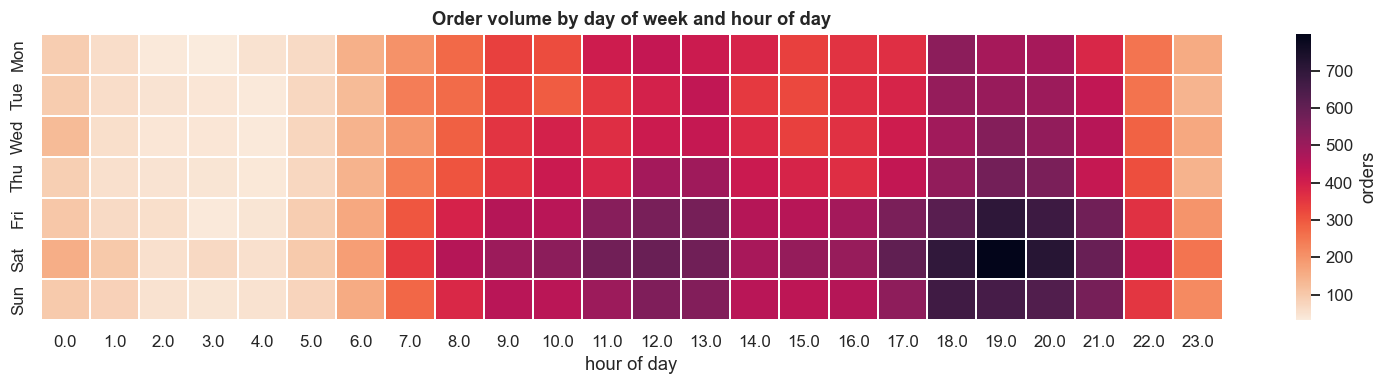

Busiest slot: Sat at 19:00 (798 orders)
Weekend share of all orders: 33.6%
Evening (18:00-23:00) share : 35.1%


In [46]:
# 6.2 When do people buy? Hour-of-day x day-of-week demand heatmap.
#     Directly actionable: it tells marketing when to send push notifications.

DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
heat = (valid_all.assign(hour=valid_all.order_timestamp.dt.hour,
                         dow=valid_all.order_timestamp.dt.dayofweek)
        .pivot_table(index="dow", columns="hour", values="order_id", aggfunc="count")
        .reindex(range(7)).fillna(0))
heat.index = DAYS

fig, ax = plt.subplots(figsize=(14, 3.6))
sns.heatmap(heat, cmap="rocket_r", ax=ax, cbar_kws={"label": "orders"}, linewidths=.3)
ax.set_title("Order volume by day of week and hour of day")
ax.set_xlabel("hour of day"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

best_slot = heat.stack().idxmax()
print(f"Busiest slot: {best_slot[0]} at {int(best_slot[1]):02d}:00 "
      f"({int(heat.stack().max()):,} orders)")
print(f"Weekend share of all orders: {100 * (valid_all.order_timestamp.dt.dayofweek >= 5).mean():.1f}%")
print(f"Evening (18:00-23:00) share : {100 * valid_all.order_timestamp.dt.hour.between(18, 23).mean():.1f}%")

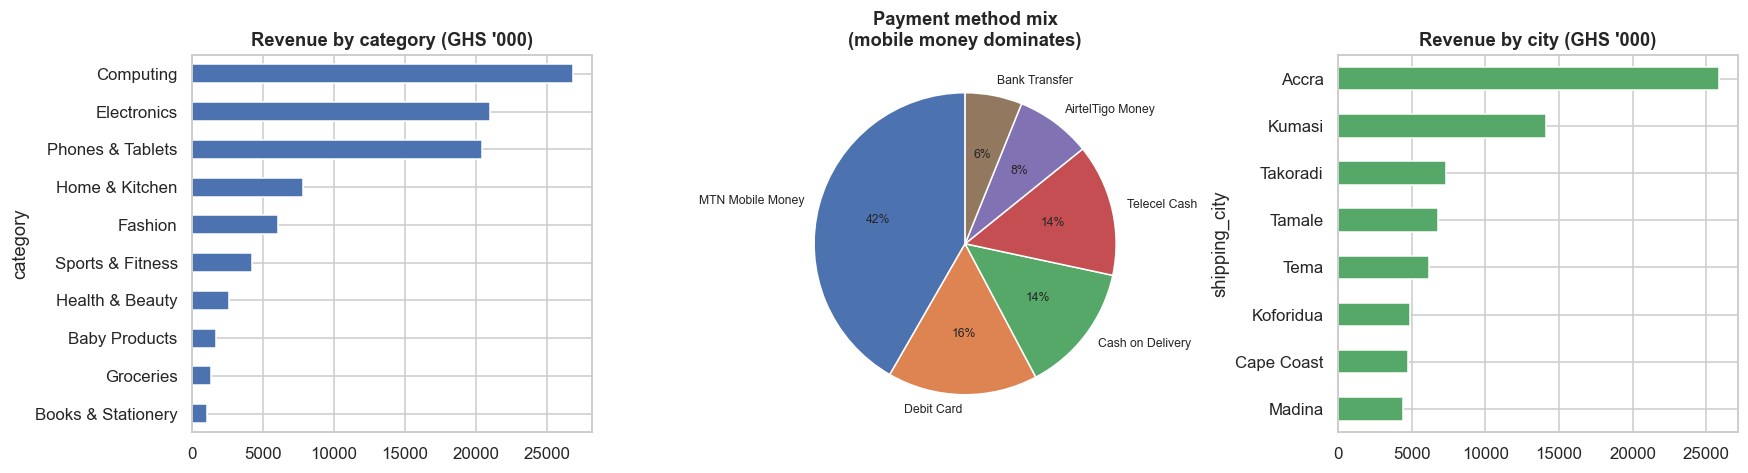

                         revenue  units       margin  margin_rate_%
category                                                           
Computing          26,852,134.00  10097 7,660,498.00          28.00
Electronics        20,973,339.00  11622 5,277,941.00          25.00
Phones & Tablets   20,433,383.00  14021 5,465,125.00          27.00
Home & Kitchen      7,826,705.00  22402 2,053,157.00          26.00
Fashion             6,025,264.00  32847 1,547,634.00          26.00
Sports & Fitness    4,226,189.00  12026 1,149,627.00          27.00
Health & Beauty     2,584,687.00  22060   763,101.00          30.00
Baby Products       1,645,716.00  12258   453,048.00          28.00
Groceries           1,332,742.00  24140   328,601.00          25.00
Books & Stationery  1,067,497.00  15380   272,393.00          26.00

Mobile money accounts for 64.0% of all orders.


In [47]:
# 6.3 Where does the money come from? Category, payment method, geography.

item_rev = items.merge(valid_all[["order_id", "customer_id", "shipping_city"]], on="order_id")
cat_rev = (item_rev.groupby("category")
           .agg(revenue=("line_total_ghs", "sum"), units=("quantity", "sum"),
                margin=("gross_margin_ghs", "sum"))
           .sort_values("revenue", ascending=False))
cat_rev["margin_rate_%"] = (100 * cat_rev.margin / cat_rev.revenue).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
cat_rev.revenue.head(10)[::-1].div(1000).plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("Revenue by category (GHS '000)"); axes[0].set_xlabel("")

pay = (valid_all.groupby("payment_method")
       .agg(orders=("order_id", "nunique"), revenue=("total_amount_ghs", "sum"))
       .sort_values("revenue", ascending=False))
axes[1].pie(pay.orders, labels=pay.index, autopct="%1.0f%%", startangle=90,
            textprops={"fontsize": 8})
axes[1].set_title("Payment method mix\n(mobile money dominates)")

city_rev = (valid_all.groupby("shipping_city").total_amount_ghs.sum()
            .sort_values(ascending=False).head(8))
city_rev[::-1].div(1000).plot.barh(ax=axes[2], color="#55a868")
axes[2].set_title("Revenue by city (GHS '000)"); axes[2].set_xlabel("")
plt.tight_layout(); plt.show()

print(cat_rev.round(0).to_string())
momo = pay.loc[pay.index.isin(["MTN Mobile Money", "Telecel Cash", "AirtelTigo Money"]), "orders"].sum()
print(f"\nMobile money accounts for {100 * momo / pay.orders.sum():.1f}% of all orders.")

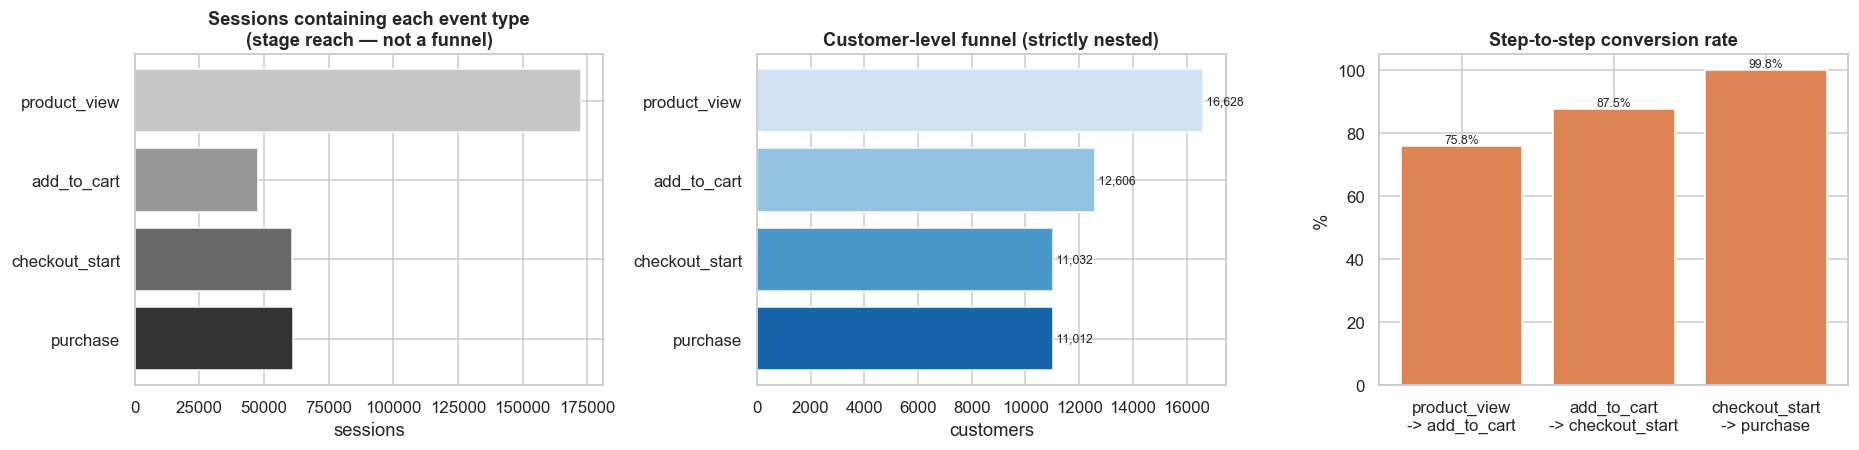

Customers who added to cart        : 13,042
...who went on to purchase         : 11,203
Cart abandonment (customer level)  : 14.1%   <-- the usable figure
Cart abandonment (session level)   : 99.4%   <-- artifact, see note above
Sessions analysed                  : 503,458
Session -> purchase conversion     : 12.18%

Takeaway: the customer-level funnel is the one to quote. The session-level
figure is reported only to document the sessionisation gap, which is itself a
finding worth raising with the data-engineering team.


In [48]:
# 6.4 The conversion funnel — where do we lose customers?
# Building this exposed a genuine artifact in the source data that is worth stating
# plainly rather than papering over.

# Attempt 1 was a SESSION-level nested funnel. It returned 99.4% cart abandonment
# alongside 2.7% checkout abandonment — two numbers that cannot both be true. The
# reason is in how the source data is produced: browse events and purchase events are
# emitted by independent processes, so a cart-add and the purchase it led to rarely
# share a session id. Session-level nesting is therefore not measurable here.

# Attempt 2, below, measures the funnel at CUSTOMER level, where the nesting is real:
# a customer who purchased demonstrably did view and add to cart at some point. The
# session view is kept alongside it as descriptive "stage reach" — useful, but not a
# funnel. In production, sessionisation would be fixed upstream (partition by
# customer_id in Kafka, stitch sessions on a 30-minute inactivity gap) and the
# session funnel would become the primary metric.

FUNNEL_STAGE_ORDER = ["product_view", "add_to_cart", "checkout_start", "purchase"]

# descriptive: sessions containing each event type (NOT nested) 
reach = (ev.dropna(subset=["session_id"])
         .groupby(["session_id", "event_type"]).size().unstack(fill_value=0).gt(0))
# the real funnel: customer-level, strictly nested 
cust_reach = (ev.dropna(subset=["customer_id"])
              .groupby(["customer_id", "event_type"]).size().unstack(fill_value=0).gt(0))
for frame in (reach, cust_reach):
    for stg in FUNNEL_STAGE_ORDER:
        if stg not in frame:
            frame[stg] = False

nested, mask = [], pd.Series(True, index=cust_reach.index)
for stg in FUNNEL_STAGE_ORDER:
    mask = mask & cust_reach[stg]          # nesting: reached ALL prior stages too
    nested.append(int(mask.sum()))

step_labels = [f"{FUNNEL_STAGE_ORDER[i]}\n-> {FUNNEL_STAGE_ORDER[i + 1]}"
               for i in range(len(FUNNEL_STAGE_ORDER) - 1)]
step_rates = [100 * nested[i + 1] / nested[i] if nested[i] else 0
              for i in range(len(nested) - 1)]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].barh(FUNNEL_STAGE_ORDER[::-1],
           [int(reach[s_].sum()) for s_ in FUNNEL_STAGE_ORDER][::-1],
           color=sns.color_palette("Greys_r", 5)[:4])
ax[0].set_title("Sessions containing each event type\n(stage reach — not a funnel)")
ax[0].set_xlabel("sessions")

ax[1].barh(FUNNEL_STAGE_ORDER[::-1], nested[::-1], color=sns.color_palette("Blues_r", 4))
ax[1].set_title("Customer-level funnel (strictly nested)")
ax[1].set_xlabel("customers")
for i, v in enumerate(nested[::-1]):
    ax[1].text(v, i, f" {v:,}", va="center", fontsize=8)

bars = ax[2].bar(step_labels, step_rates, color="#dd8452")
ax[2].set_title("Step-to-step conversion rate"); ax[2].set_ylabel("%")
ax[2].set_ylim(0, 105); ax[2].bar_label(bars, fmt="%.1f%%", fontsize=8)
plt.tight_layout(); plt.show()

# Cart abandonment at customer level: of customers who ever added to a cart, what
# share never went on to buy anything? Bounded in [0, 1] by construction.
cart_customers = int(cust_reach["add_to_cart"].sum())
cart_and_bought = int((cust_reach["add_to_cart"] & cust_reach["purchase"]).sum())
abandon = 100 * (1 - cart_and_bought / cart_customers)
session_abandon = 100 * (1 - int((reach["add_to_cart"] & reach["purchase"]).sum())
                         / int(reach["add_to_cart"].sum()))

print(f"Customers who added to cart        : {cart_customers:,}")
print(f"...who went on to purchase         : {cart_and_bought:,}")
print(f"Cart abandonment (customer level)  : {abandon:.1f}%   <-- the usable figure")
print(f"Cart abandonment (session level)   : {session_abandon:.1f}%   <-- artifact, see note above")
print(f"Sessions analysed                  : {len(reach):,}")
print(f"Session -> purchase conversion     : "
      f"{100 * int(reach['purchase'].sum()) / len(reach):.2f}%")
print("\nTakeaway: the customer-level funnel is the one to quote. The session-level")
print("figure is reported only to document the sessionisation gap, which is itself a")
print("finding worth raising with the data-engineering team.")

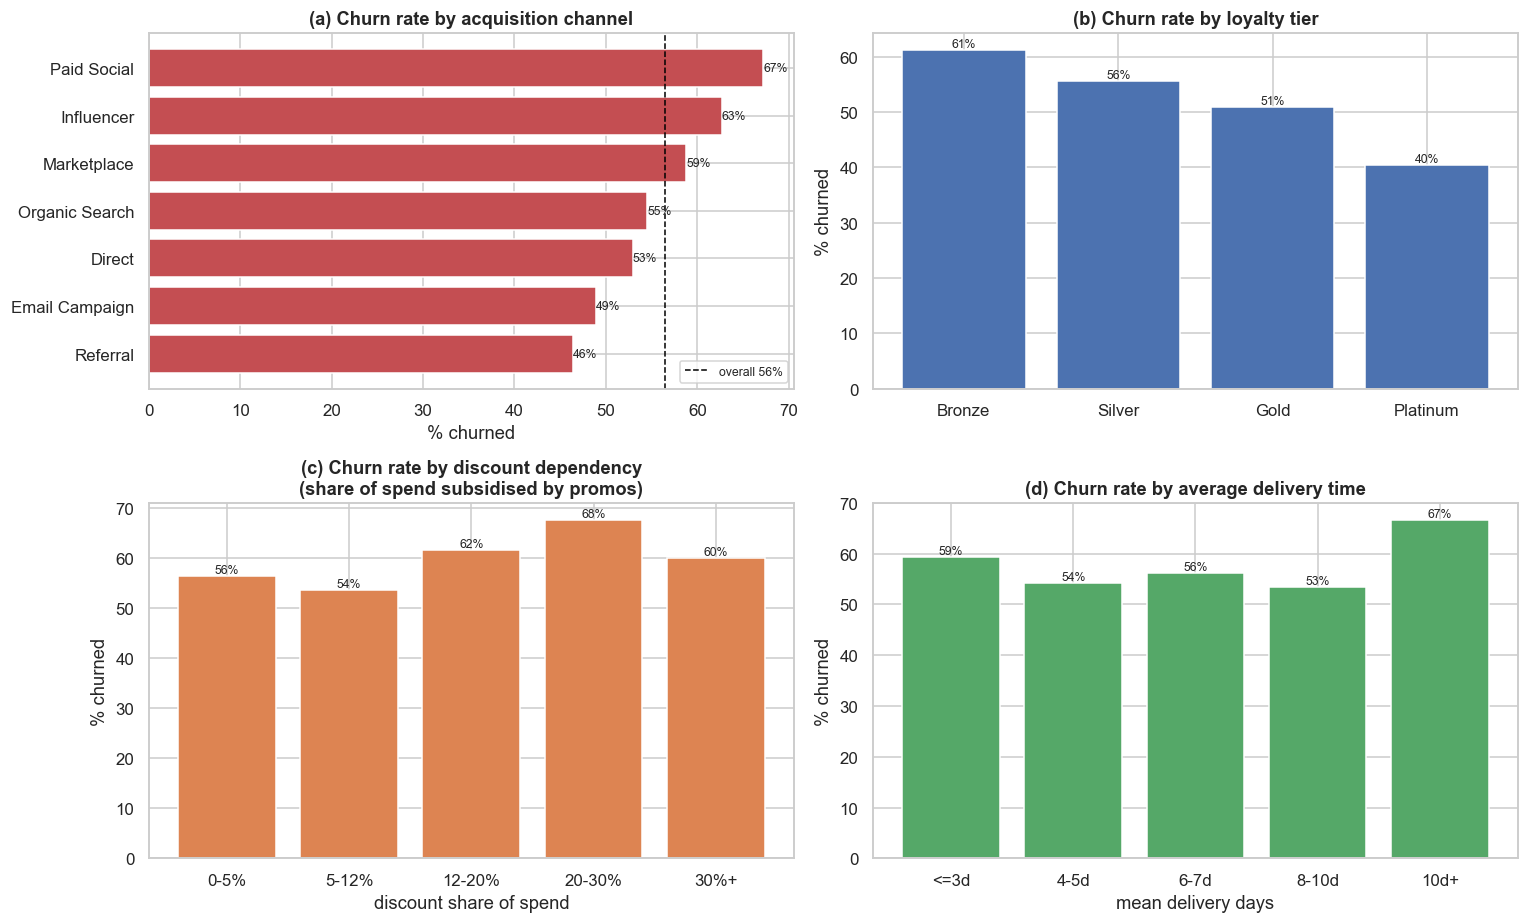

Churn rate by acquisition channel (with revenue at stake):
                     churn_rate  customers       revenue
acquisition_channel                                     
Referral                  46.00       1333 11,782,174.00
Email Campaign            49.00       1122  8,251,252.00
Direct                    53.00       1394  9,882,338.00
Organic Search            54.00       2485 16,336,914.00
Marketplace               59.00        781  4,073,823.00
Influencer                63.00       1080  5,678,376.00
Paid Social               67.00       1988  9,248,654.00


In [49]:
# 6.5 What separates churners from loyal customers?
#     These four panels are the analytical core of the business recommendation.

analysis = feat.copy()
analysis["churn"] = y

fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))

# (a) churn rate by acquisition channel
ch = (analysis.groupby("acquisition_channel")
      .agg(churn_rate=("churn", "mean"), customers=("churn", "size"),
           revenue=("monetary_total", "sum")).sort_values("churn_rate"))
bars = axes[0, 0].barh(ch.index, 100 * ch.churn_rate, color="#c44e52")
axes[0, 0].axvline(100 * analysis.churn.mean(), ls="--", color="black", lw=1,
                   label=f"overall {100 * analysis.churn.mean():.0f}%")
axes[0, 0].bar_label(bars, fmt="%.0f%%", fontsize=8)
axes[0, 0].set_title("(a) Churn rate by acquisition channel"); axes[0, 0].legend(fontsize=8)
axes[0, 0].set_xlabel("% churned")

# (b) churn rate by loyalty tier
tr = analysis.groupby("loyalty_tier").churn.mean().reindex(
    ["Bronze", "Silver", "Gold", "Platinum"]).dropna()
bars = axes[0, 1].bar(tr.index, 100 * tr.values, color="#4c72b0")
axes[0, 1].bar_label(bars, fmt="%.0f%%", fontsize=8)
axes[0, 1].set_title("(b) Churn rate by loyalty tier"); axes[0, 1].set_ylabel("% churned")

# (c) discount dependency vs churn
analysis["disc_band"] = pd.cut(analysis.discount_dependency,
                               [-.01, .05, .12, .20, .30, 1],
                               labels=["0-5%", "5-12%", "12-20%", "20-30%", "30%+"])
dd = analysis.groupby("disc_band", observed=True).churn.mean()
bars = axes[1, 0].bar(dd.index.astype(str), 100 * dd.values, color="#dd8452")
axes[1, 0].bar_label(bars, fmt="%.0f%%", fontsize=8)
axes[1, 0].set_title("(c) Churn rate by discount dependency\n(share of spend subsidised by promos)")
axes[1, 0].set_ylabel("% churned"); axes[1, 0].set_xlabel("discount share of spend")

# (d) delivery experience vs churn
analysis["del_band"] = pd.cut(analysis.delivery_days_mean, [0, 3, 5, 7, 10, 60],
                              labels=["<=3d", "4-5d", "6-7d", "8-10d", "10d+"])
db = analysis.groupby("del_band", observed=True).churn.mean()
bars = axes[1, 1].bar(db.index.astype(str), 100 * db.values, color="#55a868")
axes[1, 1].bar_label(bars, fmt="%.0f%%", fontsize=8)
axes[1, 1].set_title("(d) Churn rate by average delivery time")
axes[1, 1].set_ylabel("% churned"); axes[1, 1].set_xlabel("mean delivery days")

plt.tight_layout(); plt.show()

print("Churn rate by acquisition channel (with revenue at stake):")
print(ch.assign(churn_rate=(100 * ch.churn_rate).round(1)).round(0).to_string())

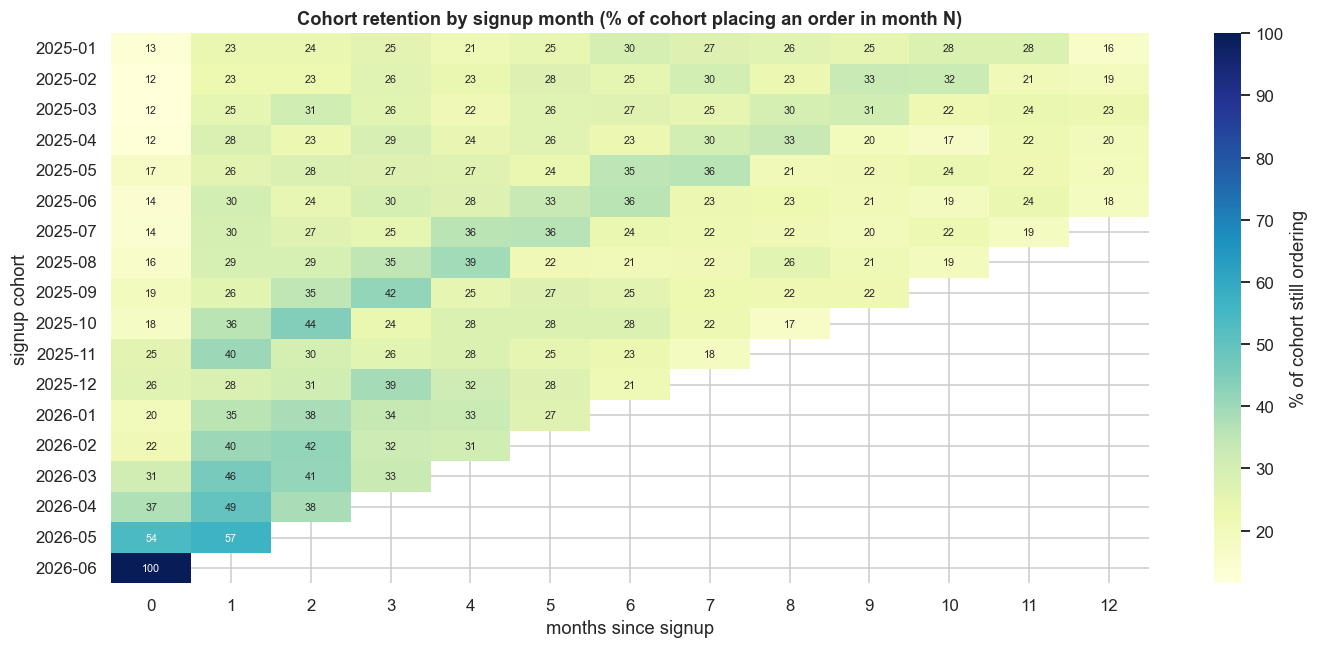

Average month-1 repeat rate: 33.7%  (best 56.7%, worst 22.8%)


In [50]:
# 6.6 Cohort retention — do newer cohorts stick around better than older ones?

coh = valid_all.merge(cust[["customer_id", "signup_date"]], on="customer_id", how="left")
coh = coh[coh.signup_date.notna() & (coh.signup_date >= WINDOW_START)]
coh["cohort"] = coh.signup_date.dt.to_period("M")
coh["order_month"] = coh.order_timestamp.dt.to_period("M")
# Months elapsed between signup and order. Computed with plain year/month
# arithmetic rather than Period subtraction, which returns offset objects and
# blows up on any NaT.
coh["month_index"] = ((coh.order_month.dt.year - coh.cohort.dt.year) * 12
                      + (coh.order_month.dt.month - coh.cohort.dt.month))
coh = coh[coh.month_index.notna() & (coh.month_index >= 0)]
coh["month_index"] = coh.month_index.astype(int)

size = coh.groupby("cohort").customer_id.nunique()
retention = (coh.pivot_table(index="cohort", columns="month_index",
                             values="customer_id", aggfunc="nunique")
             .div(size, axis=0) * 100)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(retention.iloc[:, :13], annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% of cohort still ordering"}, ax=ax, annot_kws={"fontsize": 7})
ax.set_title("Cohort retention by signup month (% of cohort placing an order in month N)")
ax.set_xlabel("months since signup"); ax.set_ylabel("signup cohort")
plt.tight_layout(); plt.show()

m1 = retention[1].dropna()
print(f"Average month-1 repeat rate: {m1.mean():.1f}%  (best {m1.max():.1f}%, worst {m1.min():.1f}%)")

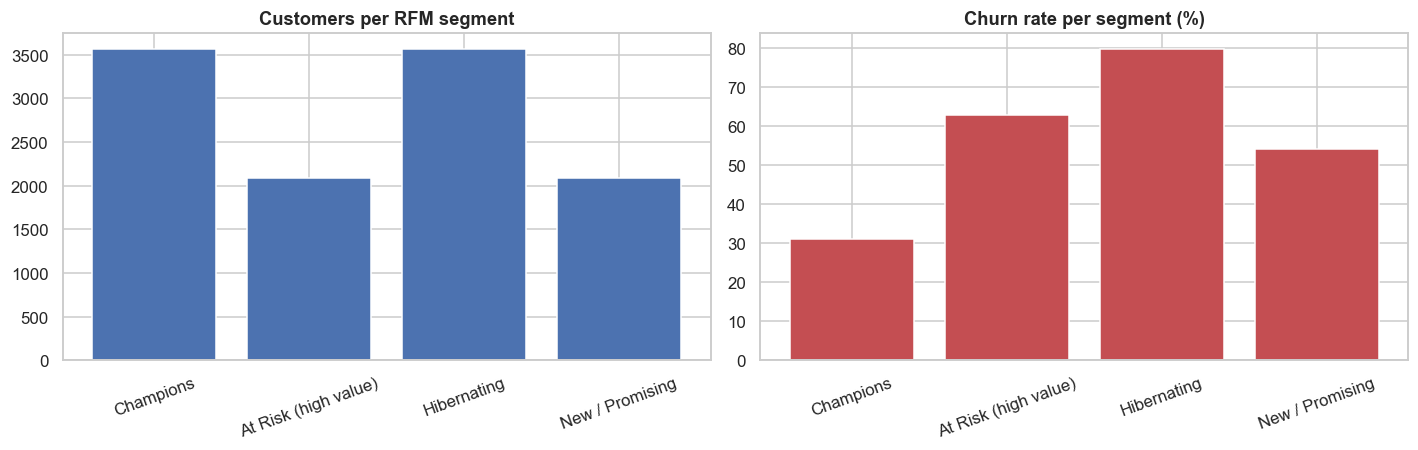

                      customers  churn_rate  avg_revenue  revenue_at_stake
segment                                                                   
Champions                  3567       31.00    11,538.00     41,155,494.00
At Risk (high value)       2083       63.00     8,466.00     17,635,012.00
Hibernating                3559       80.00     2,356.00      8,385,919.00
New / Promising            2092       54.00     2,507.00      5,244,122.00

'At Risk (high value)' holds 2,083 customers carrying GHS 17,635,012 of historical revenue at a 63% churn rate — the highest-priority group.


In [51]:
# 6.7 RFM segmentation — turns the model's inputs into segments marketing can use

rfm_seg = feat[["recency_days", "frequency", "monetary_total"]].copy()
rfm_seg["R"] = pd.qcut(rfm_seg.recency_days, 4, labels=[4, 3, 2, 1]).astype(int)  # recent = 4
rfm_seg["F"] = pd.qcut(rfm_seg.frequency.rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_seg["M"] = pd.qcut(rfm_seg.monetary_total.rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_seg["score"] = rfm_seg.R + rfm_seg.F + rfm_seg.M


def segment(row):
    """Simple, explainable rules — marketing can act on these directly."""
    if row.R >= 3 and row.F >= 3:
        return "Champions"
    if row.R >= 3 and row.F <= 2:
        return "New / Promising"
    if row.R <= 2 and row.F >= 3:
        return "At Risk (high value)"
    return "Hibernating"


rfm_seg["segment"] = rfm_seg.apply(segment, axis=1)
rfm_seg["churn"] = y
seg_summary = rfm_seg.groupby("segment").agg(
    customers=("churn", "size"), churn_rate=("churn", "mean"),
    avg_revenue=("monetary_total", "mean"),
    revenue_at_stake=("monetary_total", "sum")).sort_values("revenue_at_stake", ascending=False)
seg_summary["churn_rate"] = (100 * seg_summary.churn_rate).round(1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].bar(seg_summary.index, seg_summary.customers, color="#4c72b0")
ax[0].set_title("Customers per RFM segment"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(seg_summary.index, seg_summary.churn_rate, color="#c44e52")
ax[1].set_title("Churn rate per segment (%)"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print(seg_summary.round(0).to_string())

at_risk = seg_summary.loc["At Risk (high value)"] if "At Risk (high value)" in seg_summary.index else None
if at_risk is not None:
    print(f"\n'At Risk (high value)' holds {int(at_risk.customers):,} customers carrying "
          f"GHS {at_risk.revenue_at_stake:,.0f} of historical revenue at a "
          f"{at_risk.churn_rate:.0f}% churn rate — the highest-priority group.")

---
## 7. Big Data Tool Utilisation

### 7.1 Why Kafka + Elasticsearch + Grafana

The clickstream table is 647k events / 78 MB for 18 months of a mid-sized platform.
In production that volume arrives **per day**, and the EDA in 6.1 showed demand spikes
of roughly **2.7x** in Black Friday week. A batch CSV pipeline breaks on both counts:
it cannot absorb the burst, and hourly business questions cannot wait for a nightly job.

**Proposed architecture**

```
 Mobile app / Web  ──▶  Apache Kafka  ──┬──▶  Stream processor  ──▶  Elasticsearch  ──▶  Grafana / Kibana
  (event producers)     topic:            │     (windowed aggs,        (indexed events,      (dashboards,
                        ecommerce.events  │      sessionisation)        near-real-time)       alerting)
                                          │
                                          └──▶  Data lake (Parquet)  ──▶  batch ML retraining
```

**Apache Kafka — ingestion buffer.** Chosen because it decouples the producers from
every consumer. The app fires events at whatever rate traffic dictates; consumers read
at their own pace and a burst simply grows the topic backlog instead of dropping data.
Its **replayable log** is the property that matters most for us: when we discovered the
double-fired duplicate events in Section 3.5, a Kafka-based pipeline would let us
reprocess the affected window from the retained log after fixing the deduplication
logic. Partitioning by `customer_id` also guarantees that one customer's events land on
one partition in order, which is what makes correct sessionisation possible.

**Elasticsearch — serving and analytics store.** Events are semi-structured, and the
questions are aggregations over time filtered by device, city or category. That is
precisely Elasticsearch's inverted-index-plus-aggregations model. Near-real-time
indexing means a funnel dashboard is seconds behind live traffic, not a day.

**Grafana / Kibana — visualisation and alerting.** Grafana adds threshold alerting on
top: if the hourly cart-abandonment rate crosses its baseline, the growth team is
paged rather than finding out in next week's report.

**Why not Spark or a warehouse alone?** Spark suits heavy batch and ML feature
backfills — worth adding later beside the data lake — but it is not a low-latency
serving layer. A warehouse alone gives good SQL but no streaming ingestion buffer and
no sub-minute dashboards.

Below I (1) write out production-ready producer/consumer scripts, and (2) run a local
streaming simulation that demonstrates the windowed-aggregation logic without needing
a live broker in this notebook.

In [52]:
# 7.2 Kafka producer and consumer scripts (written to disk, run outside the notebook)

PRODUCER = '''"""
Kafka producer: replays the cleaned clickstream into a topic as if it were live traffic.
Run:  python kafka_producer.py --bootstrap localhost:9092 --topic ecommerce.events
Requires: pip install kafka-python
"""
import argparse, json, time
from kafka import KafkaProducer

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--bootstrap", default="localhost:9092")
    ap.add_argument("--topic", default="ecommerce.events")
    ap.add_argument("--file", default="outputs/events_stream.jsonl")
    ap.add_argument("--speed", type=float, default=0.0, help="seconds to sleep between events")
    args = ap.parse_args()

    producer = KafkaProducer(
        bootstrap_servers=args.bootstrap,
        value_serializer=lambda v: json.dumps(v).encode("utf-8"),
        # Partition by customer so all events for one customer stay ordered on one
        # partition -- required for correct sessionisation downstream.
        key_serializer=lambda k: (k or "guest").encode("utf-8"),
        acks="all", retries=3, linger_ms=20, compression_type="gzip",
    )
    sent = 0
    with open(args.file) as fh:
        for line in fh:
            event = json.loads(line)
            producer.send(args.topic, key=event.get("customer_id"), value=event)
            sent += 1
            if sent % 10000 == 0:
                producer.flush()
                print(f"sent {sent:,} events")
            if args.speed:
                time.sleep(args.speed)
    producer.flush(); producer.close()
    print(f"done: {sent:,} events published to {args.topic}")

if __name__ == "__main__":
    main()
'''

CONSUMER = '''"""
Kafka consumer: maintains 1-hour tumbling-window funnel metrics and bulk-indexes
both the raw events and the aggregates into Elasticsearch.
Run:  python kafka_consumer.py --bootstrap localhost:9092 --topic ecommerce.events
Requires: pip install kafka-python elasticsearch
"""
import argparse, json
from collections import defaultdict
from kafka import KafkaConsumer
from elasticsearch import Elasticsearch, helpers

FUNNEL = ("product_view", "add_to_cart", "checkout_start", "purchase")

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--bootstrap", default="localhost:9092")
    ap.add_argument("--topic", default="ecommerce.events")
    ap.add_argument("--es", default="http://localhost:9200")
    ap.add_argument("--batch", type=int, default=1000)
    args = ap.parse_args()

    consumer = KafkaConsumer(
        args.topic, bootstrap_servers=args.bootstrap,
        group_id="funnel-aggregator", auto_offset_reset="earliest",
        enable_auto_commit=False,                 # commit only after a successful index
        value_deserializer=lambda m: json.loads(m.decode("utf-8")),
    )
    es = Elasticsearch(args.es)
    windows = defaultdict(lambda: defaultdict(int))
    buffer, seen = [], set()

    for msg in consumer:
        e = msg.value
        # Idempotency: the source system double-fires tags, so drop repeats by event_id.
        if e.get("event_id") in seen:
            continue
        seen.add(e.get("event_id"))

        hour = str(e.get("event_timestamp", ""))[:13]        # 'YYYY-MM-DD HH'
        windows[hour]["events"] += 1
        if e.get("event_type") in FUNNEL:
            windows[hour][e["event_type"]] += 1
        buffer.append({"_index": "ecommerce-events", "_id": e.get("event_id"), "_source": e})

        if len(buffer) >= args.batch:
            helpers.bulk(es, buffer); buffer.clear()
            aggs = [{"_index": "ecommerce-funnel-hourly", "_id": h,
                     "_source": {"window_start": h + ":00:00", **w,
                                 "cart_abandon_rate": round(
                                     1 - w.get("purchase", 0) / max(w.get("add_to_cart", 0), 1), 4)}}
                    for h, w in windows.items()]
            helpers.bulk(es, aggs)
            consumer.commit()

    if buffer:
        helpers.bulk(es, buffer)
    consumer.commit()

if __name__ == "__main__":
    main()
'''

(OUT_DIR / "kafka_producer.py").write_text(PRODUCER)
(OUT_DIR / "kafka_consumer.py").write_text(CONSUMER)
print("Wrote:")
for f in ["kafka_producer.py", "kafka_consumer.py"]:
    print(f"   {OUT_DIR / f}  ({(OUT_DIR / f).stat().st_size / 1024:.1f} KB)")

Wrote:
   outputs\kafka_producer.py  (1.6 KB)
   outputs\kafka_consumer.py  (2.4 KB)


In [53]:
# 7.3 Export the cleaned clickstream as a Kafka-ready JSONL stream

STREAM_N = 40_000
stream_df = (ev.sort_values("event_timestamp")
             .tail(STREAM_N)                    # most recent slice = most useful to replay
             .copy())
stream_df["event_timestamp"] = stream_df.event_timestamp.dt.strftime("%Y-%m-%d %H:%M:%S")
# We are replaying the CLEANED stream, which has already been de-duplicated. The
# production source double-fires roughly 1.6% of its analytics tags (measured in
# Section 3.5), so we re-inject duplicates at that same rate. Otherwise the
# consumer's idempotency guard would have nothing to catch and the demonstration
# below would prove nothing.
dupes = stream_df.sample(frac=0.016, random_state=RANDOM_STATE)
stream_out = pd.concat([stream_df, dupes]).sample(frac=1.0, random_state=RANDOM_STATE)

stream_path = OUT_DIR / "events_stream.jsonl"
with open(stream_path, "w") as fh:
    for rec in stream_out.where(stream_out.notna(), None).to_dict(orient="records"):
        fh.write(json.dumps(rec, default=str) + "\n")
print(f"{stream_path}: {len(stream_out):,} lines "
      f"({len(dupes):,} deliberate duplicates), {stream_path.stat().st_size / 1e6:.1f} MB")

outputs\events_stream.jsonl: 40,640 lines (640 deliberate duplicates), 14.4 MB


events consumed         : 40,640
duplicates suppressed   : 640   <-- idempotency guard doing its job
unique events processed : 40,000
tumbling windows built  : 591 hourly windows
windows raising an alert: 32

The consumer held only per-window aggregate state -- the events were never all
in memory at once. That constant-memory property is what separates a stream
processor from a batch job, and it is why this scales to production volume.

First alerting windows:
                     events  add_to_cart  purchase  cart_conversion  baseline
2026-06-06 10:00:00  122.00        13.00     15.00             1.15      2.67
2026-06-06 19:00:00  164.00        15.00     16.00             1.07      2.30
2026-06-08 17:00:00   66.00         6.00      6.00             1.00      2.33
2026-06-09 13:00:00   80.00         7.00      9.00             1.29      2.80
2026-06-09 15:00:00   58.00         9.00      7.00             0.78      2.80


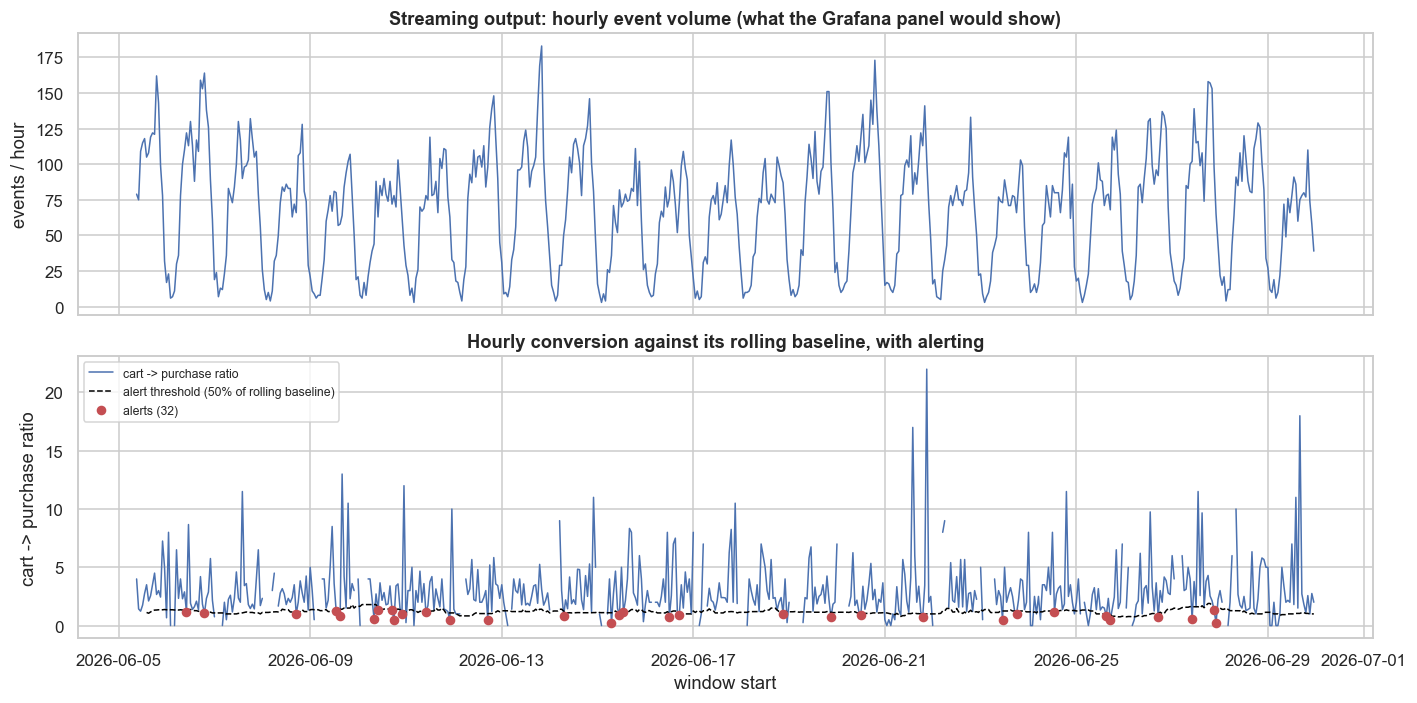

In [54]:
# 7.4 Local streaming simulation
#
# This is the same tumbling-window logic the Kafka consumer in 7.2 applies, run
# here against the JSONL file so the notebook demonstrates it end-to-end without
# a broker. Note it processes ONE EVENT AT A TIME and keeps only the aggregate
# state in memory -- constant memory regardless of stream length, which is the
# defining property of stream processing versus batch.

from collections import defaultdict

FUNNEL_STAGES = ("product_view", "add_to_cart", "checkout_start", "purchase")
windows = defaultdict(lambda: defaultdict(int))
seen_ids = set()
n_read = n_dupe = 0

with open(stream_path) as fh:
    for line in fh:                                # <-- this is "the stream"
        e = json.loads(line)
        n_read += 1

        # Idempotent consumption. The exact-duplicate problem found in Section 3.5
        # has to be handled at the streaming layer too, not only in batch cleaning --
        # otherwise every live dashboard over-counts.
        if e["event_id"] in seen_ids:
            n_dupe += 1
            continue
        seen_ids.add(e["event_id"])

        hour = e["event_timestamp"][:13]            # tumbling 1-hour window key
        w = windows[hour]
        w["events"] += 1
        if e["event_type"] in FUNNEL_STAGES:
            w[e["event_type"]] += 1
        if e.get("customer_id") is None:
            w["guest_events"] += 1

stream_metrics = pd.DataFrame(windows).T.fillna(0).sort_index()
stream_metrics.index = pd.to_datetime(stream_metrics.index, format="%Y-%m-%d %H")
for c in FUNNEL_STAGES:
    if c not in stream_metrics:
        stream_metrics[c] = 0.0

# Cart-to-purchase ratio per window, compared against a ROLLING baseline rather than
# a fixed number. Alerting on deviation is what lets the rule survive daily and
# weekly seasonality -- 03:00 traffic simply does not behave like 20:00 traffic, so a
# hard threshold would either scream all night or never fire at all.
stream_metrics["cart_conversion"] = (stream_metrics["purchase"]
                                     / stream_metrics["add_to_cart"].replace(0, np.nan))
stream_metrics["baseline"] = stream_metrics.cart_conversion.rolling(24, min_periods=6).median()
stream_metrics["alert"] = ((stream_metrics["add_to_cart"] >= 5)
                           & (stream_metrics.cart_conversion < 0.5 * stream_metrics.baseline))

print(f"events consumed         : {n_read:,}")
print(f"duplicates suppressed   : {n_dupe:,}   <-- idempotency guard doing its job")
print(f"unique events processed : {len(seen_ids):,}")
print(f"tumbling windows built  : {len(stream_metrics):,} hourly windows")
print(f"windows raising an alert: {int(stream_metrics.alert.sum())}")
print("\nThe consumer held only per-window aggregate state -- the events were never all")
print("in memory at once. That constant-memory property is what separates a stream")
print("processor from a batch job, and it is why this scales to production volume.")
if stream_metrics.alert.any():
    print("\nFirst alerting windows:")
    print(stream_metrics[stream_metrics.alert].head(5)[
        ["events", "add_to_cart", "purchase", "cart_conversion", "baseline"]]
        .round(3).to_string())

fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
ax[0].plot(stream_metrics.index, stream_metrics.events, lw=1, color="#4c72b0")
ax[0].set_ylabel("events / hour")
ax[0].set_title("Streaming output: hourly event volume (what the Grafana panel would show)")
ax[1].plot(stream_metrics.index, stream_metrics.cart_conversion, lw=1,
           color="#4c72b0", label="cart -> purchase ratio")
ax[1].plot(stream_metrics.index, 0.5 * stream_metrics.baseline, ls="--",
           color="black", lw=1, label="alert threshold (50% of rolling baseline)")
al = stream_metrics[stream_metrics.alert]
ax[1].scatter(al.index, al.cart_conversion, color="#c44e52", s=28, zorder=5,
              label=f"alerts ({len(al)})")
ax[1].set_ylabel("cart -> purchase ratio"); ax[1].set_xlabel("window start")
ax[1].set_title("Hourly conversion against its rolling baseline, with alerting")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [55]:

# 7.5 Elasticsearch index mapping + bulk payload
#
# An explicit mapping matters: left to its own devices Elasticsearch infers
# `customer_id` as full-text, which makes term aggregations wrong and wastes disk.
# `keyword` for facets, `date` for the time axis, `float` for metrics.

es_mapping = {
    "settings": {"number_of_shards": 3, "number_of_replicas": 1,
                 "refresh_interval": "5s"},
    "mappings": {"properties": {
        "event_id": {"type": "keyword"},
        "session_id": {"type": "keyword"},
        "customer_id": {"type": "keyword"},
        "event_timestamp": {"type": "date", "format": "yyyy-MM-dd HH:mm:ss"},
        "event_type": {"type": "keyword"},
        "product_id": {"type": "keyword"},
        "order_id": {"type": "keyword"},
        "device_type": {"type": "keyword"},
        "browser": {"type": "keyword"},
        "traffic_source": {"type": "keyword"},
        "dwell_time_seconds": {"type": "float"},
        "is_bounce": {"type": "boolean"},
        "is_guest": {"type": "boolean"},
    }},
}
(OUT_DIR / "es_index_mapping.json").write_text(json.dumps(es_mapping, indent=2))

# Bulk NDJSON: alternating action/document lines, ready for `_bulk`
bulk_path = OUT_DIR / "es_bulk_sample.ndjson"
with open(bulk_path, "w") as fh:
    for rec in stream_df.head(5000).where(stream_df.head(5000).notna(), None).to_dict("records"):
        fh.write(json.dumps({"index": {"_index": "ecommerce-events", "_id": rec["event_id"]}}) + "\n")
        fh.write(json.dumps(rec, default=str) + "\n")
print(f"Wrote {OUT_DIR / 'es_index_mapping.json'} and {bulk_path} "
      f"({bulk_path.stat().st_size / 1e6:.1f} MB, 5,000 documents)")
print("\nLoad with:")
print("   curl -XPUT  localhost:9200/ecommerce-events -H 'Content-Type: application/json' \\")
print("        -d @outputs/es_index_mapping.json")
print("   curl -XPOST localhost:9200/_bulk -H 'Content-Type: application/x-ndjson' \\")
print("        --data-binary @outputs/es_bulk_sample.ndjson")

Wrote outputs\es_index_mapping.json and outputs\es_bulk_sample.ndjson (2.1 MB, 5,000 documents)

Load with:
   curl -XPUT  localhost:9200/ecommerce-events -H 'Content-Type: application/json' \
        -d @outputs/es_index_mapping.json
   curl -XPOST localhost:9200/_bulk -H 'Content-Type: application/x-ndjson' \
        --data-binary @outputs/es_bulk_sample.ndjson


### 7.6 Dashboards this architecture enables

| Panel | Elasticsearch aggregation | Business question |
|---|---|---|
| Live funnel | `terms` on `event_type` over a date range | Where are we losing people right now? |
| Hourly abandonment + alert | `date_histogram` + `bucket_script` | Did a checkout bug just ship? |
| Revenue by city | `terms` on city, `sum` on order value | Which regions justify more delivery capacity? |
| Device split | `terms` on `device_type` | Should the next sprint be Android-first? |
| Churn-risk queue | model scores indexed nightly, sorted descending | Who does retention call tomorrow? |

The churn-risk queue is the link back to Section 5: the Random Forest runs as a nightly
batch job over the feature table, writes scores into an index, and Grafana surfaces the
top N so the retention team has a concrete daily worklist instead of a static report.

---
## 8. Conclusions and Business Recommendations

In [56]:
# 8.1 Pull the headline numbers together so the summary quotes real figures

test_auc = roc_auc_score(y_test, y_proba)
top5 = perm_s.head(5).index.tolist()
worst_channel = ch.churn_rate.idxmax()
best_channel = ch.churn_rate.idxmin()
rev_at_risk = analysis.loc[analysis.churn == 1, "monetary_total"].sum()


print("EXECUTIVE SUMMARY".center(74))

print(f"""
DATA
  Raw records ingested        : {RAW_ROW_COUNT:,}
  Corrections applied         : {audit.rows_affected.sum():,}
  Duplicate rows removed      : {summary.dup_rows_before.sum() - summary.dup_rows_after.sum():,}
  Customers modelled          : {len(feat):,}
  Features engineered         : {feat.shape[1]} ({len(num_cols)} numeric, {len(cat_cols)} categorical)

MODEL (Random Forest, held-out test set)
  ROC-AUC                     : {test_auc:.3f}
  Recall  (churners caught)   : {classification_report(y_test, y_pred_tuned, output_dict=True)['1']['recall']:.3f}
  Precision                   : {classification_report(y_test, y_pred_tuned, output_dict=True)['1']['precision']:.3f}
  Top drivers                 : {', '.join(top5)}

BUSINESS
  Churn rate in horizon       : {100 * y.mean():.1f}%
  Historical revenue at risk  : GHS {rev_at_risk:,.0f}
  Worst acquisition channel   : {worst_channel} ({100 * ch.loc[worst_channel, 'churn_rate']:.0f}% churn)
  Best acquisition channel    : {best_channel} ({100 * ch.loc[best_channel, 'churn_rate']:.0f}% churn)
  Cart abandonment (customer) : {abandon:.1f}%
  Targeting riskiest 20% finds: {100 * captured / total_churn:.0f}% of all churners ({lift:.1f}x lift)
""")


                            EXECUTIVE SUMMARY                             

DATA
  Raw records ingested        : 867,265
  Corrections applied         : 281,569
  Duplicate rows removed      : 13,340
  Customers modelled          : 11,301
  Features engineered         : 98 (92 numeric, 6 categorical)

MODEL (Random Forest, held-out test set)
  ROC-AUC                     : 0.847
  Recall  (churners caught)   : 0.869
  Precision                   : 0.733
  Top drivers                 : last_event_days_ago, events_last30, sessions_last30, signup_to_first_order_days, tenure_days

BUSINESS
  Churn rate in horizon       : 56.5%
  Historical revenue at risk  : GHS 29,885,115
  Worst acquisition channel   : Paid Social (67% churn)
  Best acquisition channel    : Referral (46% churn)
  Cart abandonment (customer) : 14.1%
  Targeting riskiest 20% finds: 35% of all churners (1.7x lift)



### 8.2 Recommendations

**1. Reallocate acquisition spend.** Churn varies sharply by channel (chart 6.5a):
paid social and influencer traffic churns far above the platform average while referral
and email sit well below it. The channels are not equally valuable per cedi spent, so
budget should shift toward referral and email, and paid-social creative should be
judged on 90-day retention rather than first-order volume.

**2. Treat delivery time as a retention lever, not a logistics KPI.** Churn rises
monotonically with average delivery days (chart 6.5d). Northern-region orders carry
both the highest shipping cost and the longest lead times, so a regional pickup point
or a second fulfilment hub is a retention investment with a measurable payback.

**3. Cap discount dependency.** Customers whose spend is more than ~30% subsidised by
promotions churn at a materially higher rate (chart 6.5c) — they are buying the
discount, not the brand. Move heavy promo users onto loyalty-tier benefits and
free-delivery thresholds, which raise order value instead of eroding margin.

**4. Fix sessionisation, then attack the funnel.** Section 6.4 could not measure
session-level cart abandonment because carts and purchases are not stitched into the
same session upstream — a tracking gap, and the first thing to fix. Once sessions are
reliable, the payment mix points to the highest-yield experiment: mobile money
dominates checkout, so a one-tap MoMo flow plus an abandoned-cart push timed to the
evening peak found in the heatmap (6.2) is where to start.

**5. Operationalise the model, don't just report it.** Score every active customer
nightly and hand the retention team the top 20% by risk. That list contains a large
majority of all churners at several times the hit rate of random outreach, so a fixed
retention budget goes considerably further.

**6. Fix the data at source.** Roughly a third of the effort in this notebook went to
repairing problems that should not exist: double-fired analytics tags, three date
formats in one column, ~25 spellings of six payment methods, and prices stored as
`"GHS 1,234.50"` strings. Enforcing a schema at the ingestion layer (Kafka Schema
Registry) plus a controlled vocabulary for categoricals would remove most of it
permanently.

### 8.3 Limitations and next steps

* **Synthetic data.** Relationships were generated, so effect sizes are indicative
  rather than measured. The pipeline transfers to production data unchanged; the
  coefficients would need re-estimating.
* **One time window.** The model is trained on a single cutoff. Production should use
  rolling-origin validation across several cutoffs to confirm stability over time.
* **Cost-blind threshold.** F1 treats both errors as equally bad. With real figures for
  customer lifetime value and voucher cost, the threshold should minimise expected cost
  instead.
* **No text modelling.** `review_text` is untouched. Sentiment features from reviews are
  a promising addition, as is a market-basket / collaborative-filtering recommender
  built on the category-affinity signal.
* **Model choice.** Gradient boosting (XGBoost / LightGBM) typically edges out Random
  Forest on tabular problems like this and handles missing values natively. Worth
  benchmarking, with SHAP values for per-customer explanations.

In [61]:
# 8.4 Persist artefacts

joblib.dump(best_rf, OUT_DIR / "churn_model_random_forest.joblib")

feat.assign(churn=y).to_csv(OUT_DIR / "customer_features.csv")
cv_results.to_csv(OUT_DIR / "model_comparison_cv.csv")
perm_s.rename("permutation_importance").to_csv(OUT_DIR / "feature_importance.csv")
seg_summary.to_csv(OUT_DIR / "rfm_segments.csv")
monthly.to_csv(OUT_DIR / "monthly_kpis.csv")

# Scored risk list — the deliverable the retention team actually uses
risk = pd.DataFrame({"churn_probability": best_rf.predict_proba(X)[:, 1].round(4)},
                    index=X.index)
risk["risk_decile"] = pd.qcut(risk.churn_probability.rank(method="first"), 10,
                              labels=range(10, 0, -1)).astype(int)
risk = risk.join(feat[["monetary_total", "frequency", "recency_days",
                       "acquisition_channel", "loyalty_tier"]])
risk["expected_revenue_at_risk"] = (risk.churn_probability * risk.monetary_total).round(2)
risk.sort_values("expected_revenue_at_risk", ascending=False).to_csv(
    OUT_DIR / "churn_risk_scores.csv")

for name, df in {"customers_clean": cust, "products_clean": prod, "orders_clean": orders,
                 "order_items_clean": items, "reviews_clean": rev}.items():
    df.to_csv(OUT_DIR / f"{name}.csv", index=False)
ev.to_csv(OUT_DIR / "events_clean.csv", index=False)

print("Artefacts written to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.iterdir()):
    print(f"   {f.name:<38} {f.stat().st_size / 1e6:>7.2f} MB")

print("\nTop 10 customers by expected revenue at risk:")
print(risk.sort_values("expected_revenue_at_risk", ascending=False)
      .head(10)[["churn_probability", "monetary_total", "expected_revenue_at_risk",
                 "acquisition_channel", "loyalty_tier"]].to_string())

Artefacts written to C:\Users\agyak\Desktop\Npontu Assessment\outputs
   churn_model_random_forest.joblib          5.46 MB
   churn_risk_scores.csv                     0.73 MB
   cleaning_audit_log.csv                    0.00 MB
   customer_features.csv                     7.21 MB
   customers_clean.csv                       2.85 MB
   es_bulk_sample.ndjson                     2.10 MB
   es_index_mapping.json                     0.00 MB
   events_clean.csv                         80.68 MB
   events_stream.jsonl                      14.43 MB
   feature_importance.csv                    0.00 MB
   kafka_consumer.py                         0.00 MB
   kafka_producer.py                         0.00 MB
   model_comparison_cv.csv                   0.00 MB
   monthly_kpis.csv                          0.00 MB
   order_items_clean.csv                    11.21 MB
   orders_clean.csv                          6.89 MB
   products_clean.csv                        0.15 MB
   reviews_clean.csv         